# D_S2.0 — Metrics Analysis (Direct from S2)

Analyses the deterministic metrics computed in S2 **without permutation testing**.

- 27 families (26 signal F01–F26 + Null) × 201 SNR × 10 reps = 54,270 cases
- Null family (f(x)=0, 2,010 cases) serves as empirical null distribution
- Detection threshold: metric value exceeds 95th percentile of Null distribution

Data sources:
- `output/S1/cases.csv` + `scatter_points.npz`
- `output/S2/metrics_full.parquet`

In [1049]:
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')

## Load Data

In [1050]:
# ── Variant-level switches ──
USE_STRONG   = False   # ← include strong features (default ON)
USE_STANDARD = True  # ← include standard features (default OFF)
USE_MILD     = False  # ← include mild features (default OFF)

cases = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
metrics = pd.read_parquet(S2_DIR / 'metrics_full.parquet')

meta_cols = ['case_id', 'family_id', 'family_name', 'snr', 'spread_pattern',
             'x_distribution', 'category', 'direction', 'linearity',
             'monotonicity', 'special_shape', 'replicate', 'variant_level']
meta = cases[[c for c in meta_cols if c in cases.columns]].copy()

df = metrics.merge(meta, on='case_id', how='left')

# Convert SNR to float for sorting
df['snr_val'] = df['snr'].apply(lambda x: float('inf') if str(x) == 'inf' else float(x))

# Filter by variant_level
allowed_levels = []
if USE_STRONG:   allowed_levels.append('strong')
if USE_STANDARD: allowed_levels.append('standard')
if USE_MILD:     allowed_levels.append('mild')
allowed_levels.append('none')  # Null family always has 'none'

df = df[df['variant_level'].isin(allowed_levels)].copy()

# Also filter cases so scatter-plot cells only show selected variants
cases = cases[cases['variant_level'].isin(allowed_levels)].copy()

# Signal = all 26 families (not Null)
signal = df[df['family_id'] != 'Null'].copy()
null_df = df[df['category'] == 'true_null'].copy()

print(f'Variant levels: {allowed_levels}')
print(f'Total: {len(df):,} cases')
print(f'Signal (26 families): {len(signal):,}')
print(f'Null (true_null): {len(null_df):,}')
print(f'\nFamilies: {sorted(signal["family_id"].unique())}')
print(f'SNR levels: {signal["snr_val"].nunique()} unique values')
print(f'Replicates per (family, SNR): {signal.groupby(["family_id","snr"]).size().median():.0f}')
print(f'\nMetric columns: {len(metrics.columns) - 1}')


Variant levels: ['standard', 'none']
Total: 54,270 cases
Signal (26 families): 52,260
Null (true_null): 2,010

Families: ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26']
SNR levels: 201 unique values
Replicates per (family, SNR): 10

Metric columns: 76


In [1051]:
# Shared color palette: fresh pastels for F01–F12, muted earth tones for F13–F26
FAMILY_PALETTE = {
    'F01': '#4FC3F7',  'F02': '#29B6F6',  'F03': '#81C784',  'F04': '#26C6DA',
    'F05': '#AED581',  'F06': '#43A047',  'F07': '#F48FB1',  'F08': '#CE93D8',
    'F09': '#80DEEA',  'F10': '#80CBC4',  'F11': '#FFE082',  'F12': '#F9A825',
    'F13': '#8D6E63',  'F14': '#A1887F',  'F15': '#78909C',  'F16': '#90A4AE',
    'F17': '#C62828',  'F18': '#AD1457',  'F19': '#6A1B9A',  'F20': '#4527A0',
    'F21': '#1565C0',  'F22': '#00838F',  'F23': '#2E7D32',  'F24': '#FF7043',
    'F25': '#D84315',  'F26': '#4E342E',  'Null': '#BDBDBD',
}

SHORT = {
    'F01': 'Linear(+)',     'F02': 'Linear(−)',     'F03': 'PwrCvx(+)',
    'F04': 'PwrCvx(−)',    'F05': 'PwrCcv(+)',     'F06': 'PwrCcv(−)',
    'F07': 'Sat(+)',        'F08': 'Sat(−)',        'F09': 'Log(+)',
    'F10': 'Log(−)',        'F11': 'Exp(+)',        'F12': 'Exp(−)',
    'F13': 'S-crv(+)',      'F14': 'S-crv(−)',      'F15': 'Thresh(+)',
    'F16': 'Thresh(−)',     'F17': 'Peak(∩)',       'F18': 'Valley(∪)',
    'F19': 'Spike',         'F20': 'Inv Spike',     'F21': 'Cubic',
    'F22': 'Oscillation',       'F23': 'Two Lines',     'F24': 'L+Parab',
    'F25': 'Multi-reg',     'F26': 'Windowed J',
}


## Gallery — Diverse Scatterplot Samples

A 3×6 grid sampling different function families and noise levels,
giving a quick visual sense of the variety of shapes in the dataset.

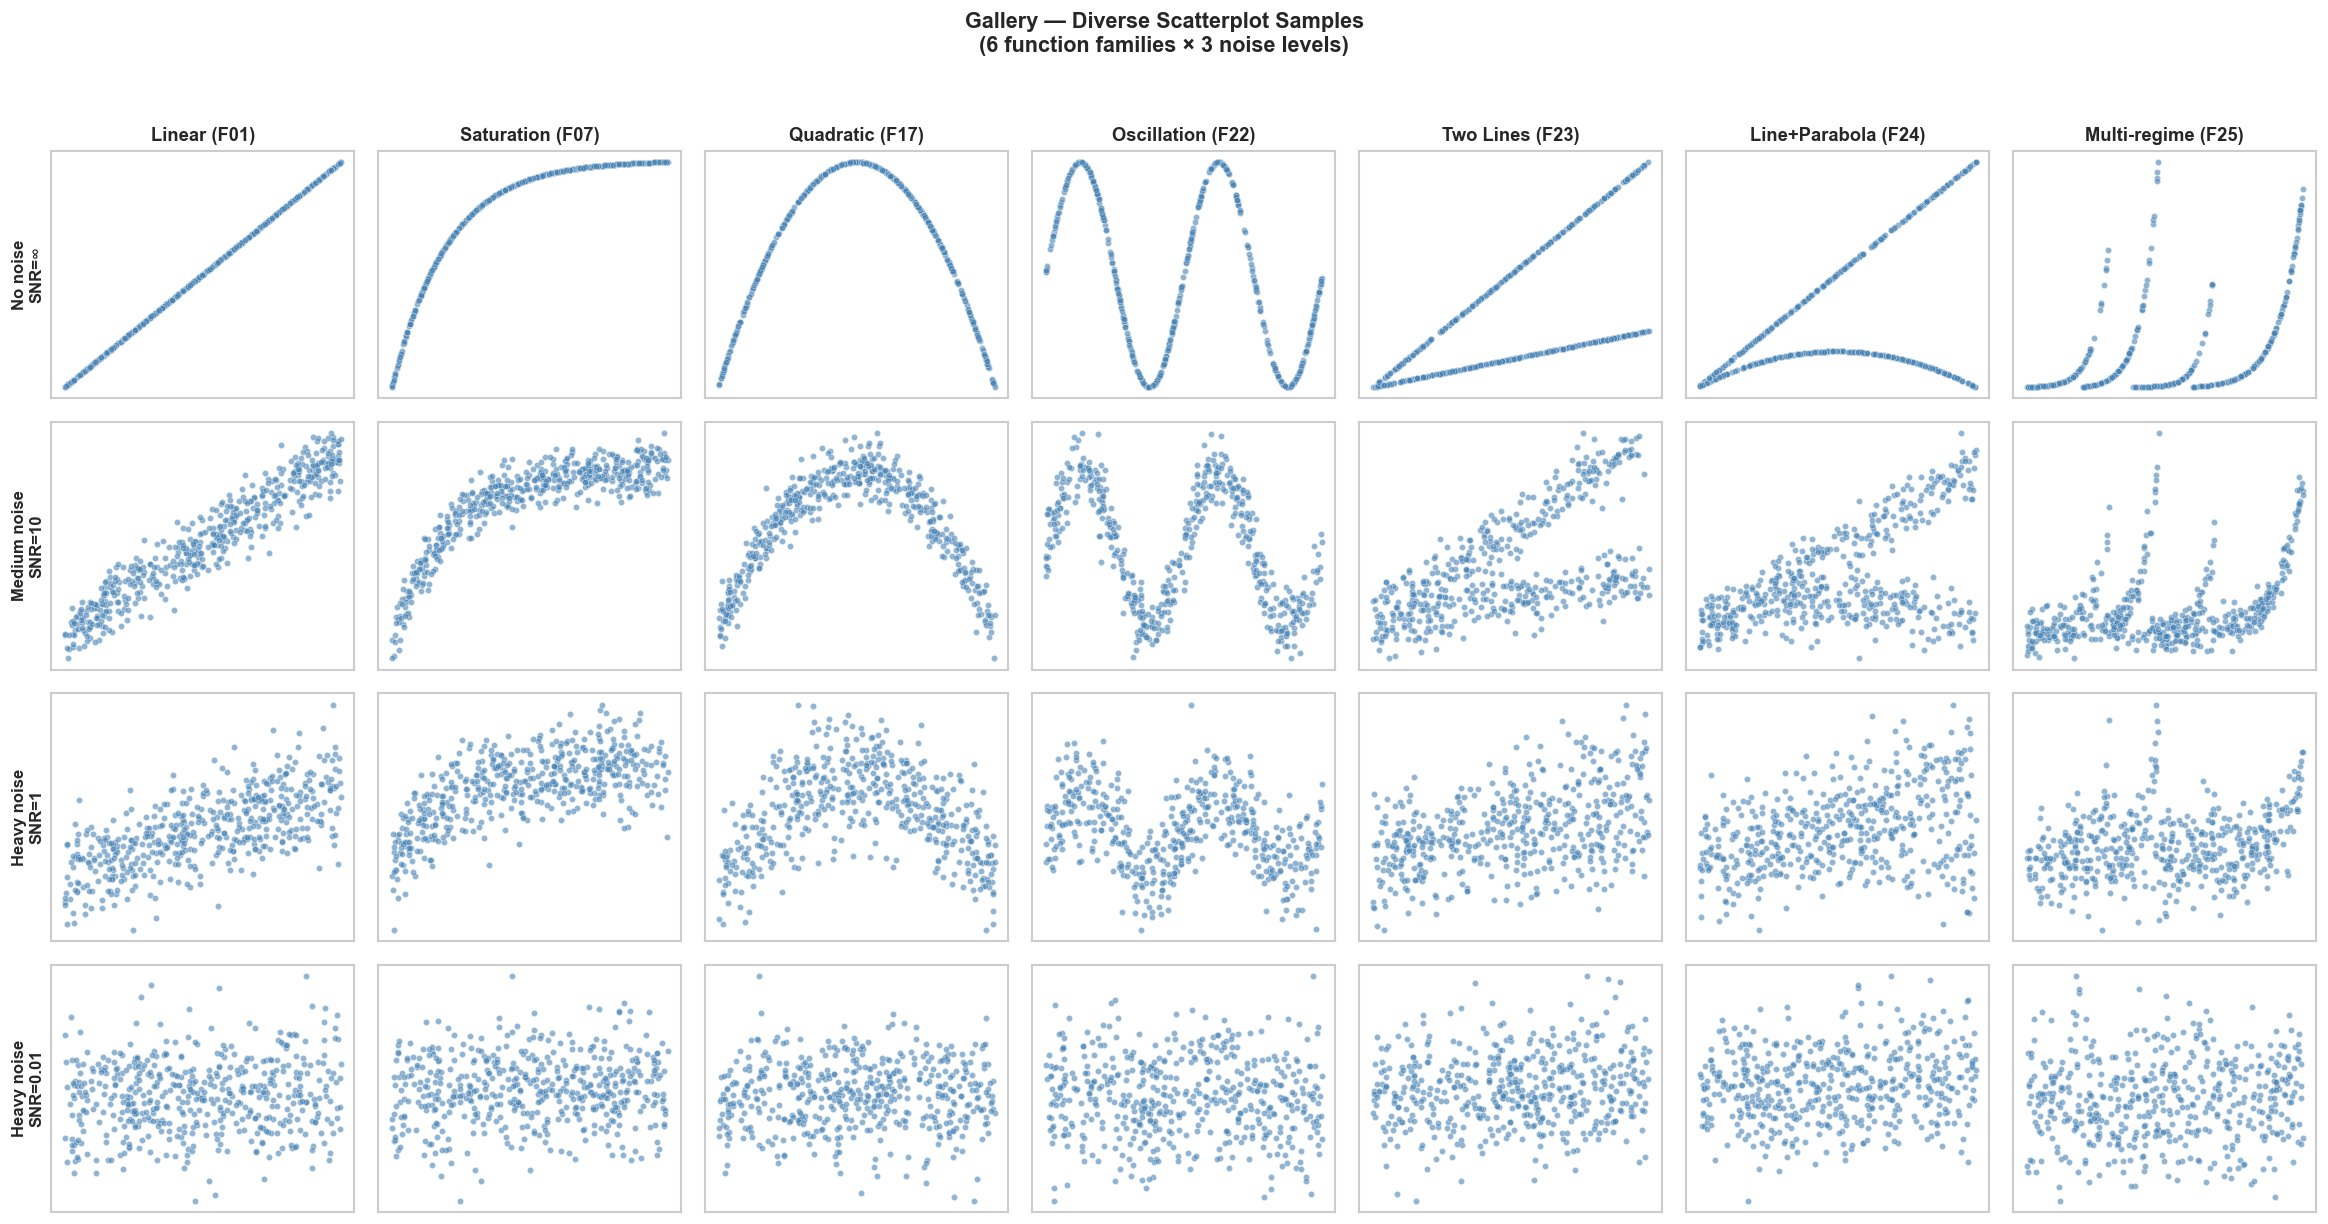

In [1052]:
# ── Gallery: diverse scatterplots (7 families × 3 noise levels) ──

pts = np.load(S1_DIR / 'scatter_points.npz')
x_pts, y_pts = pts['x'], pts['y']
case_id_to_idx = dict(zip(cases['case_id'], cases.index))

gallery_families = [
    ('F01', 'Linear'),
    ('F07', 'Saturation'),
    ('F17', 'Quadratic'),
    ('F22', 'Oscillation'),
    ('F23', 'Two Lines'),
    ('F24', 'Line+Parabola'),
    ('F25', 'Multi-regime'),
]

finite_snr = sorted([s for s in signal['snr_val'].unique() if np.isfinite(s)])
gallery_snr = [
    (float('inf'), 'No noise'),
    (min(finite_snr, key=lambda s: abs(s - 10)),  'Medium noise'),
    (min(finite_snr, key=lambda s: abs(s - 1)), 'Heavy noise'),
    (min(finite_snr, key=lambda s: abs(s - 0.01)), 'Heavy noise'),
]

nrows = len(gallery_snr)
ncols = len(gallery_families)

fig, axes = plt.subplots(nrows, ncols, figsize=(2.8 * ncols, 2.5 * nrows))

for ri, (sv, noise_label) in enumerate(gallery_snr):
    for ci, (fam_id, fam_label) in enumerate(gallery_families):
        ax = axes[ri, ci]

        match = df[(df['family_id'] == fam_id) &
                   (df['snr_val'] == sv) &
                   (df['replicate'] == 0)]

        if len(match) > 0:
            row = match.iloc[0]
            idx = case_id_to_idx[row['case_id']]
            x, y = x_pts[idx], y_pts[idx]
            ax.scatter(x, y, s=14, alpha=0.6, color='steelblue',
                       edgecolors='white', linewidths=0.3)

        if ri == 0:
            ax.set_title(f'{fam_label} ({fam_id})', fontsize=11, fontweight='bold')
        if ci == 0:
            snr_str = 'SNR=\u221e' if math.isinf(sv) else f'SNR={sv:.2g}'
            ax.set_ylabel(f'{noise_label}\n{snr_str}', fontsize=10, fontweight='bold')

        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle('Gallery \u2014 Diverse Scatterplot Samples\n'
             '(6 function families \u00d7 3 noise levels)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

del x_pts, y_pts

## Overview — 26 Function Families + Null

5×6 grid showing one representative scatterplot per family at SNR ≈ 50.

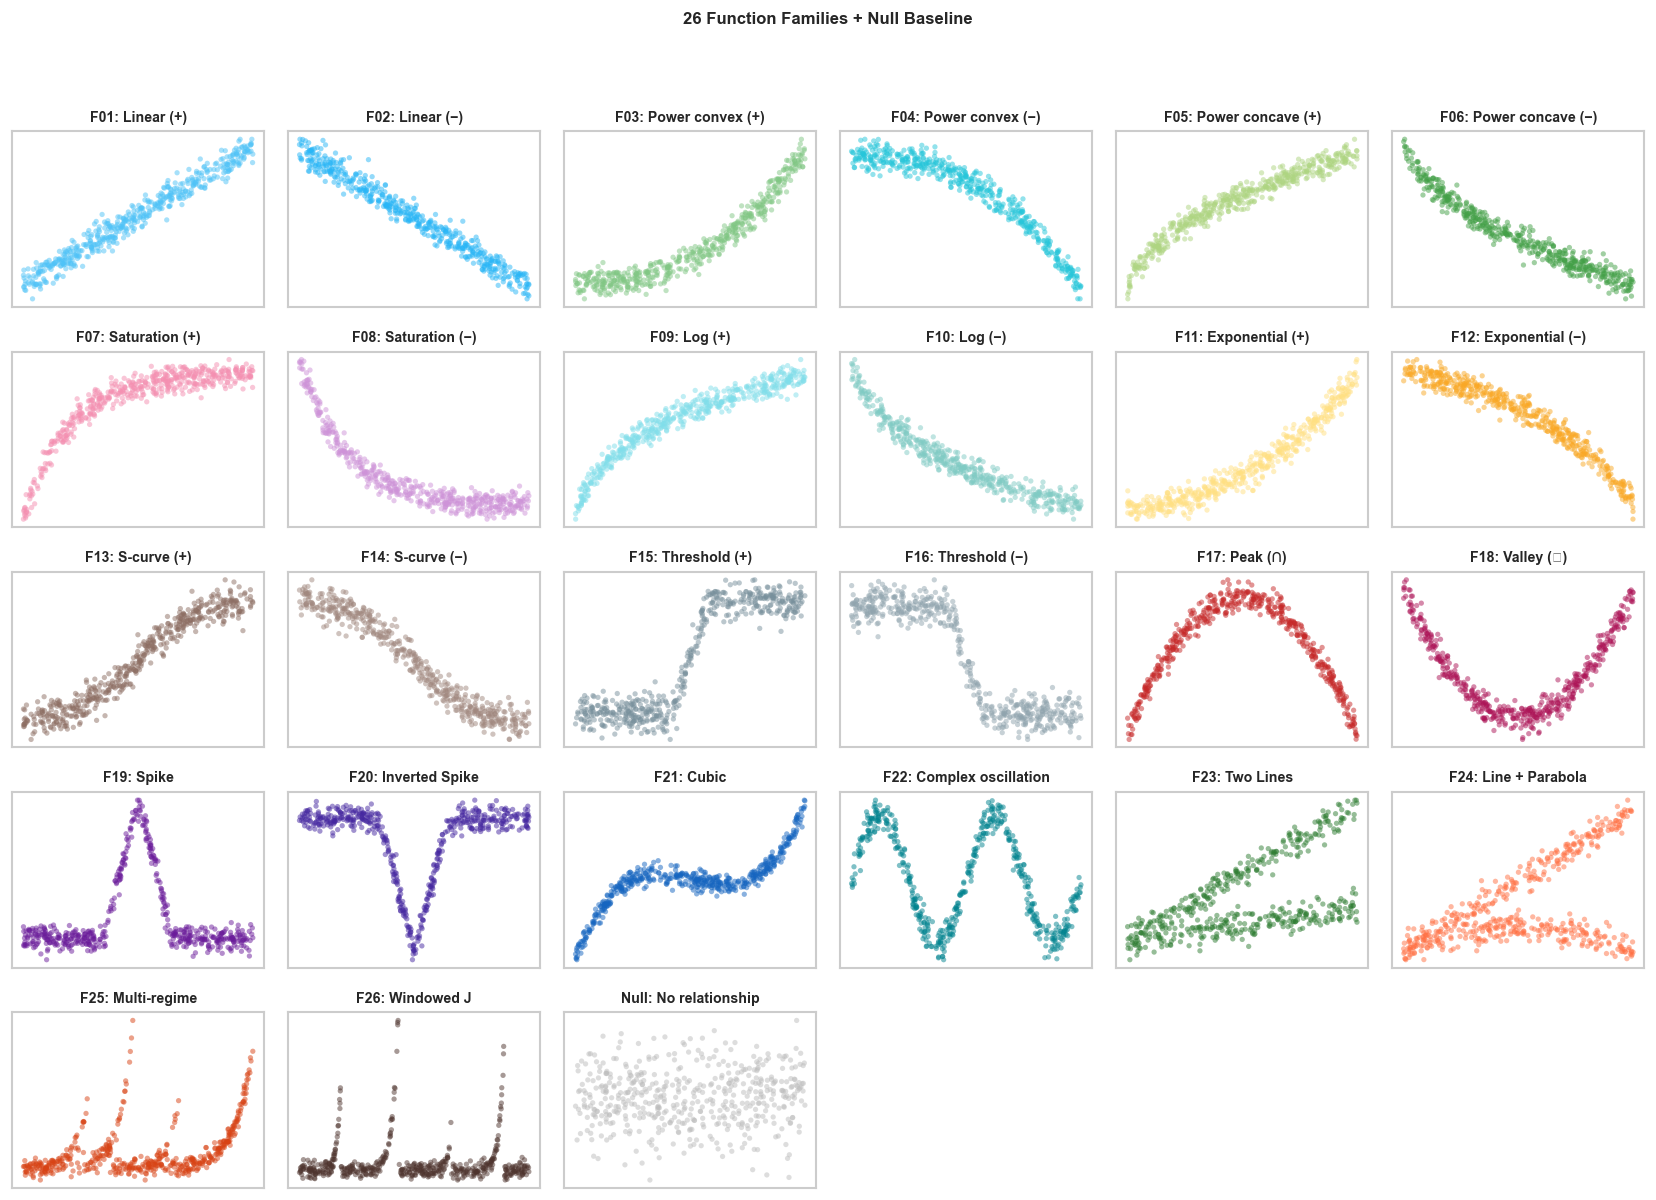

In [1053]:
# ── 5×6 Overview: all 26 families + Null ──

pts = np.load(S1_DIR / 'scatter_points.npz')
x_all, y_all = pts['x'], pts['y']

overview_snr = 30.0
finite_snrs = [s for s in cases['snr'].unique()
               if str(s) != 'inf' and str(s) != 'nan']
finite_snrs = [float(s) for s in finite_snrs]
closest_overview_snr = min(finite_snrs, key=lambda s: abs(s - overview_snr))

all_family_ids = [f'F{i:02d}' for i in range(1, 27)] + ['Null']

SHORT_NAMES = {
    'F01': 'Linear (+)',       'F02': 'Linear (−)',
    'F03': 'Power convex (+)', 'F04': 'Power convex (−)',
    'F05': 'Power concave (+)','F06': 'Power concave (−)',
    'F07': 'Saturation (+)',   'F08': 'Saturation (−)',
    'F09': 'Log (+)',          'F10': 'Log (−)',
    'F11': 'Exponential (+)',  'F12': 'Exponential (−)',
    'F13': 'S-curve (+)',      'F14': 'S-curve (−)',
    'F15': 'Threshold (+)',    'F16': 'Threshold (−)',
    'F17': 'Peak (∩)',         'F18': 'Valley (∪)',
    'F19': 'Spike',            'F20': 'Inverted Spike',
    'F21': 'Cubic',            'F22': 'Complex oscillation',
    'F23': 'Two Lines',        'F24': 'Line + Parabola',
    'F25': 'Multi-regime',
    'F26': 'Windowed J',
    'Null': 'No relationship',
}

fig, axes = plt.subplots(5, 6, figsize=(14, 10))
fig.suptitle('26 Function Families + Null Baseline',
             fontsize=10, fontweight='bold', y=1.0)

for idx, (ax, fam_id) in enumerate(zip(axes.flat, all_family_ids)):
    label = SHORT_NAMES[fam_id]
    color = FAMILY_PALETTE.get(fam_id, '#5b9bd5')

    fam_cases = cases[(cases['family_id'] == fam_id) &
                      (cases['snr'] == closest_overview_snr) &
                      (cases['replicate'] == 0)]

    if len(fam_cases) > 0:
        case_idx = fam_cases.index[0]
        ax.scatter(x_all[case_idx], y_all[case_idx], s=10, alpha=0.5,
                   color=color, edgecolors='none')

    ax.set_title(f'{fam_id}: {label}', fontsize=8.5, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(all_family_ids):]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

del x_all, y_all, pts

## Panel C — Metric Value vs SNR by Function Family

Each subplot shows one metric. X-axis = SNR (log scale, strong→weak left→right).  
Y-axis = metric value. Each family is a colored line (mean over 10 replicates).

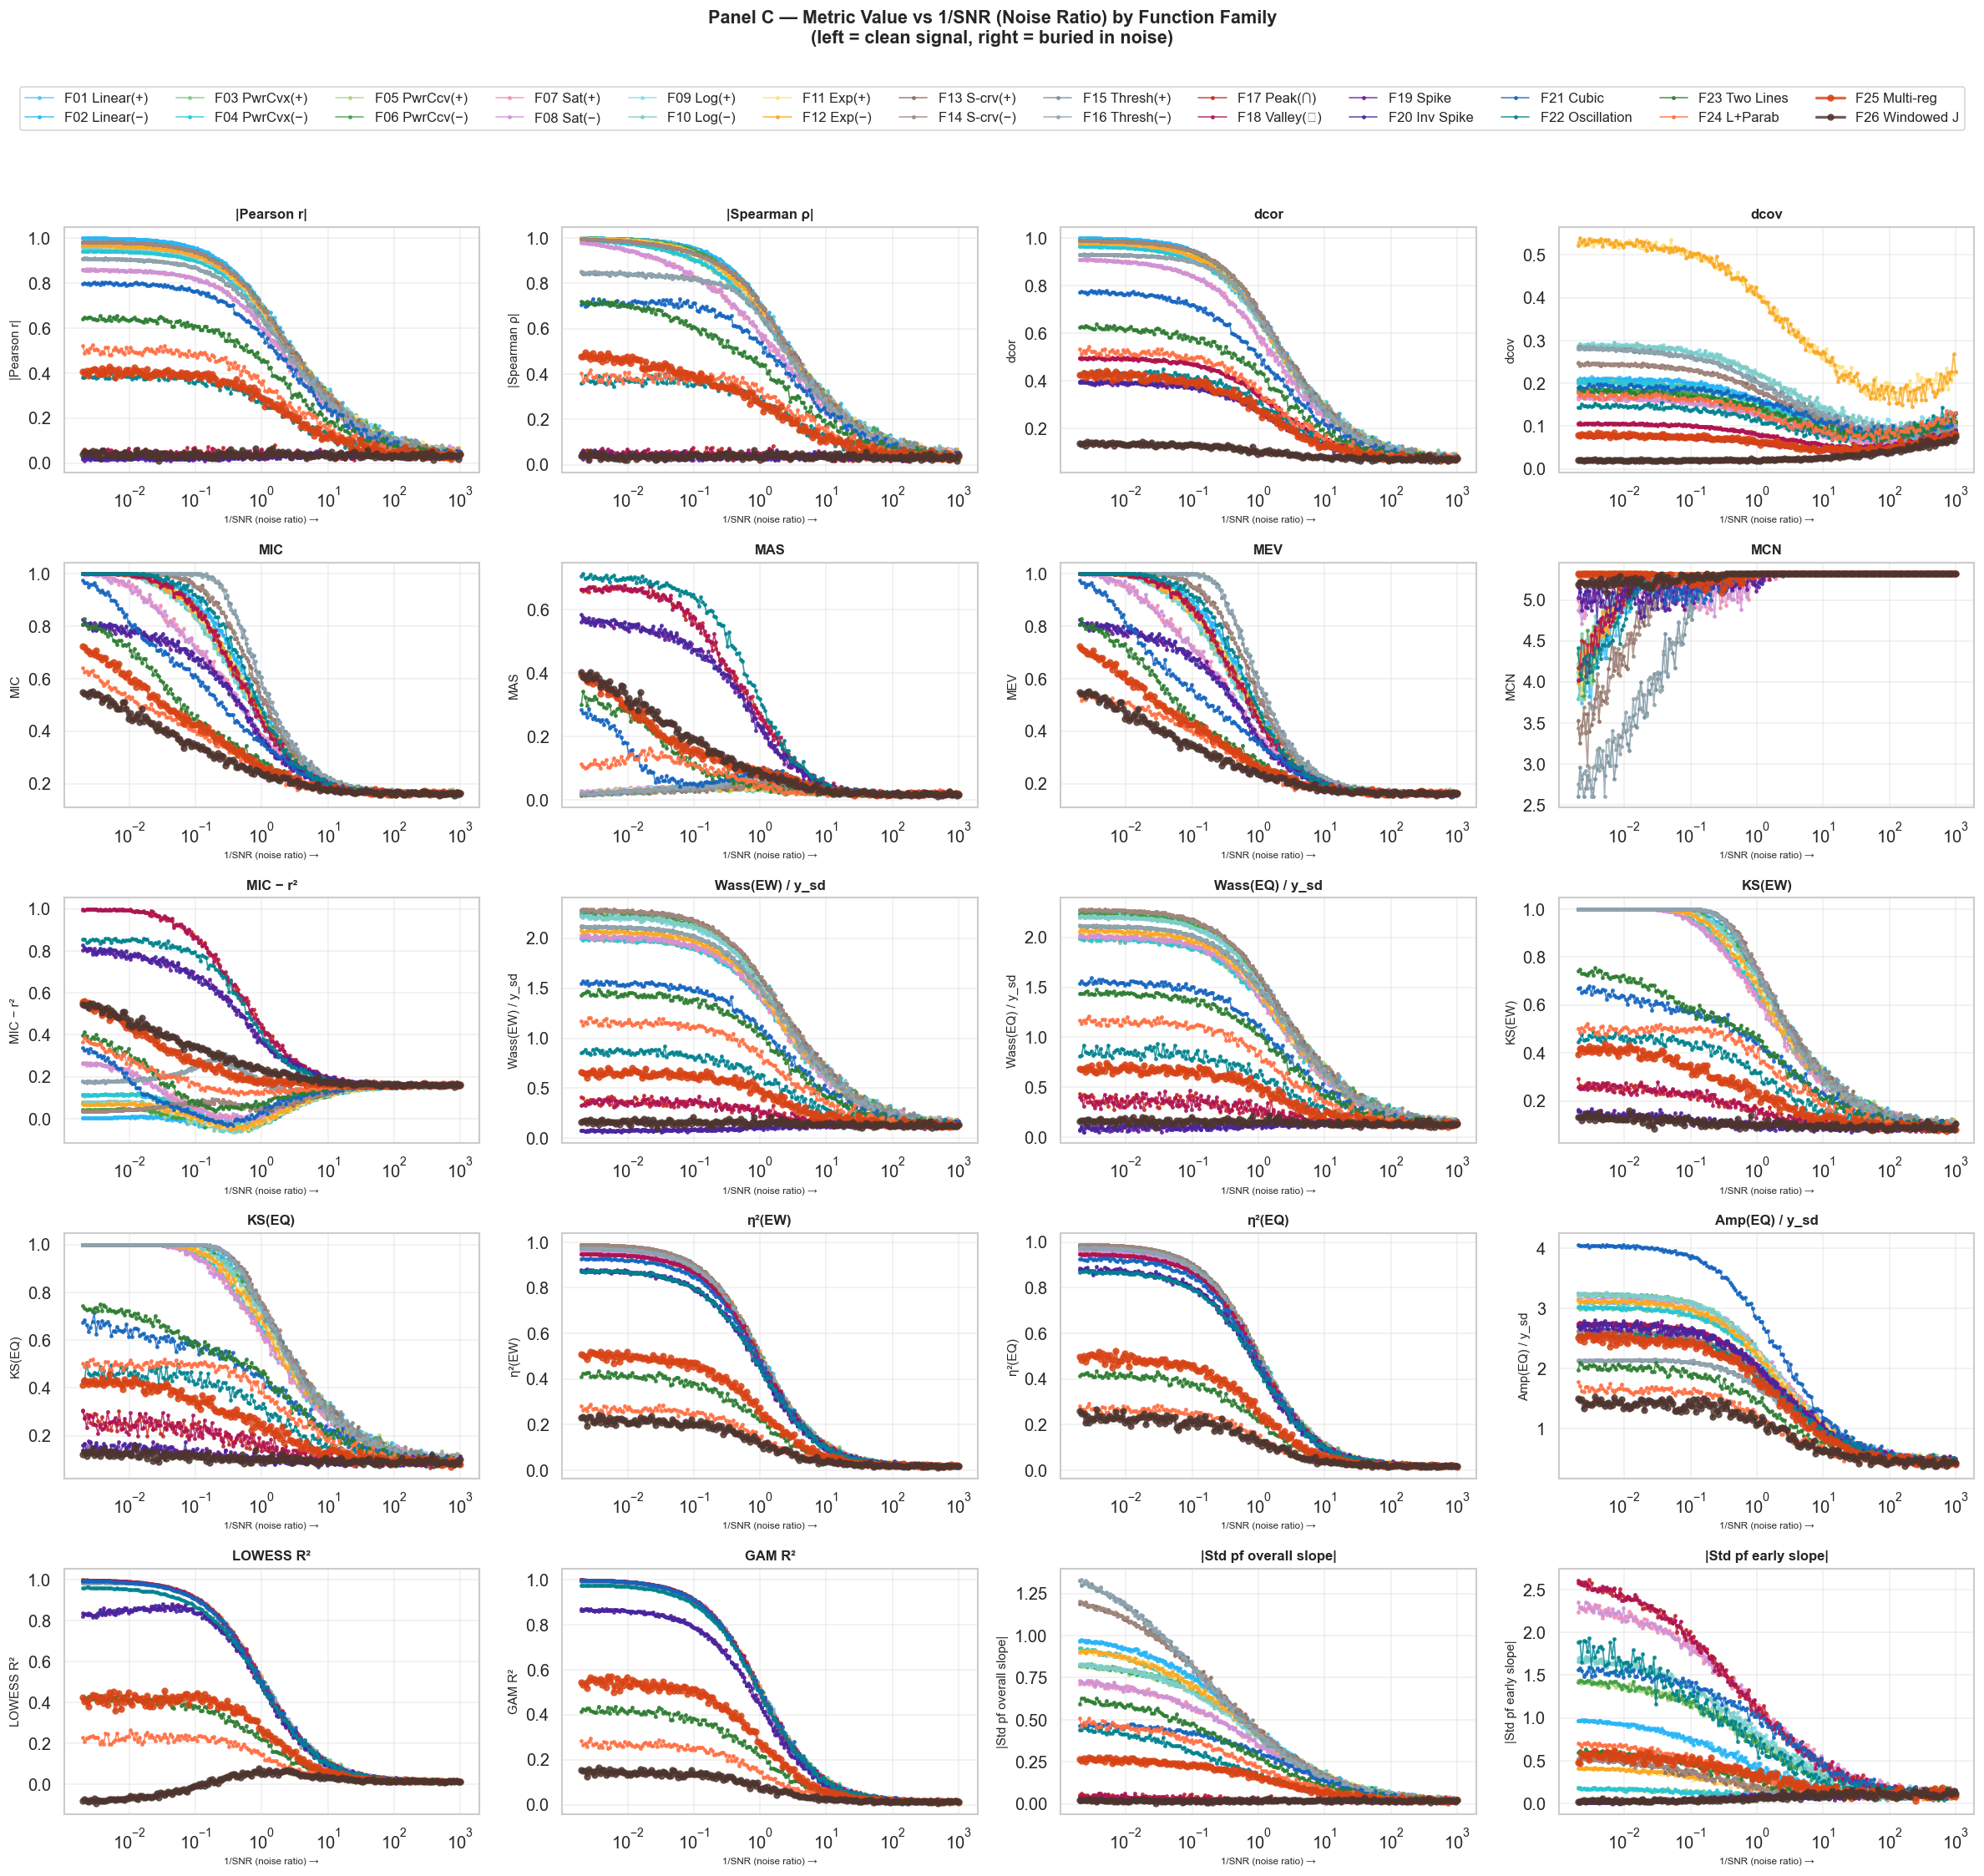

In [1054]:
# ── Panel C: Metric value vs Noise Ratio (1/SNR) by function family ──


PANEL_METRICS = [
    ('pearson_r',            '|Pearson r|'),
    ('spearman_rho',         '|Spearman ρ|'),
    ('distance_correlation', 'dcor'),
    ('distance_covariance',  'dcov'),
    ('MIC',                  'MIC'),
    ('MAS',                  'MAS'),
    ('MEV',                  'MEV'),
    ('MCN',                  'MCN'),
    ('MIC_minus_r2',         'MIC − r²'),
    ('equal_width_distribution_wasserstein_distance_div_y_sd',  'Wass(EW) / y_sd'),
    ('equal_count_distribution_wasserstein_distance_div_y_sd',  'Wass(EQ) / y_sd'),
    ('equal_width_distribution_ks_distance',                    'KS(EW)'),
    ('equal_count_distribution_ks_distance',                    'KS(EQ)'),
    ('equal_width_bin_eta_squared',             'η²(EW)'),
    ('equal_count_bin_eta_squared',             'η²(EQ)'),
    ('equal_count_bin_amplitude_div_y_sd',      'Amp(EQ) / y_sd'),
    ('lowess_r2',            'LOWESS R²'),
    ('gam_r2',              'GAM R²'),
    ('standardized_polyfit_overall_slope',  '|Std pf overall slope|'),
    ('standardized_polyfit_early_slope',    '|Std pf early slope|'),
]

ABS_METRICS = {'pearson_r', 'spearman_rho',
               'standardized_polyfit_overall_slope',
               'standardized_polyfit_early_slope'}

family_ids = sorted(signal['family_id'].unique())

ncols = 4
nrows = math.ceil(len(PANEL_METRICS) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

for ax_i, (col, label) in enumerate(PANEL_METRICS):
    ax = axes[ax_i]
    for fid in family_ids:
        sub = signal[signal['family_id'] == fid].copy()
        vals = sub[col].copy()
        if col in ABS_METRICS:
            vals = vals.abs()
        sub = sub.assign(_val=vals)
        agg = sub.groupby('snr_val')['_val'].mean().reset_index()
        agg = agg[np.isfinite(agg['snr_val']) & (agg['snr_val'] > 0)].copy()
        agg['noise_ratio'] = 1.0 / agg['snr_val']
        agg = agg.sort_values('noise_ratio')
        lw = 2.0 if fid in ('F25', 'F26') else 1.0
        ms = 4.0 if fid in ('F25', 'F26') else 2.0
        ax.plot(agg['noise_ratio'], agg['_val'], '-o',
                color=FAMILY_PALETTE[fid],
                markersize=ms, linewidth=lw, alpha=0.8,
                label=f'{fid} {SHORT.get(fid, "")}')
    ax.set_xscale('log')
    ax.set_xlabel('1/SNR (noise ratio) →', fontsize=7)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3)

for ax_i in range(len(PANEL_METRICS), len(axes)):
    axes[ax_i].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=13,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, 1.03))
fig.suptitle('Panel C — Metric Value vs 1/SNR (Noise Ratio) by Function Family\n'
             '(left = clean signal, right = buried in noise)',
             fontsize=13, fontweight='bold', y=1.07)
plt.tight_layout()
plt.show()


## Panel D — Key Metrics: Fresh vs Muted Families

Top row: F01–F12 (simple monotonic/symmetric shapes).  
Bottom row: F13–F26 (complex, multi-branch, threshold shapes).

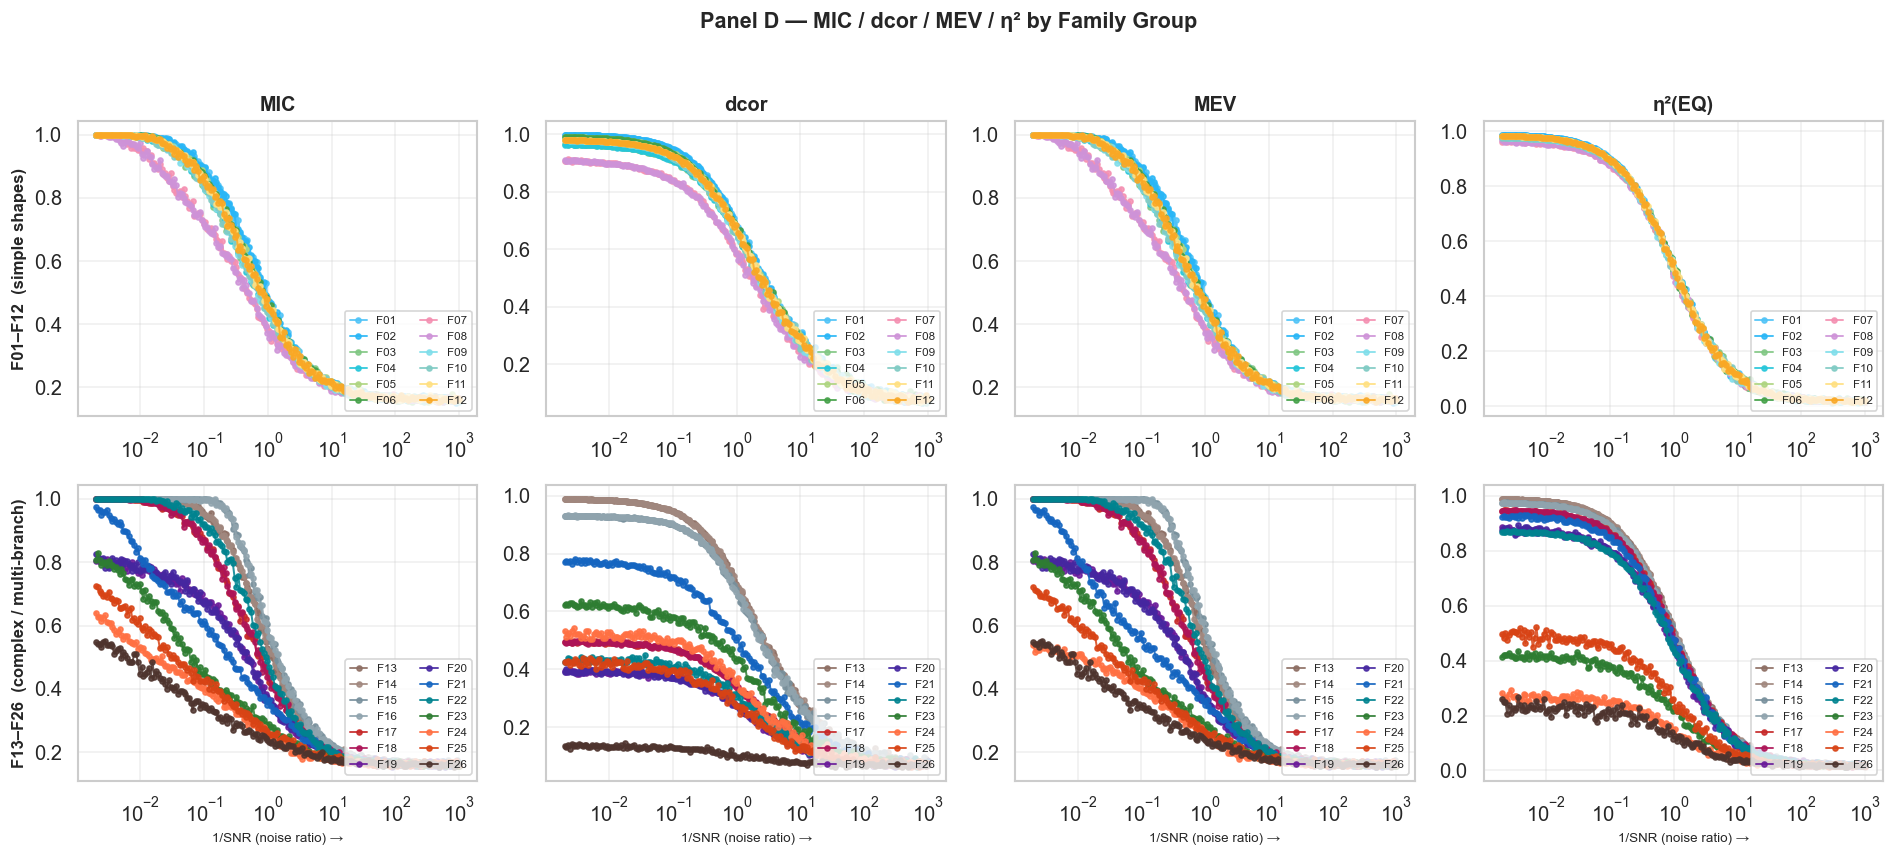

In [1055]:
# ── Panel D: Key metrics split by family group ──

SPLIT_METRICS = [
    ('MIC',                  'MIC'),
    ('distance_correlation', 'dcor'),
    ('MEV',                  'MEV'),
    ('equal_count_bin_eta_squared', 'η²(EQ)'),
]

group1 = [f'F{i:02d}' for i in range(1, 13)]
group2 = [f'F{i:02d}' for i in range(13, 27)]
groups = [
    (group1, 'F01–F12  (simple shapes)'),
    (group2, 'F13–F26  (complex / multi-branch)'),
]

fig, axes = plt.subplots(2, len(SPLIT_METRICS),
                         figsize=(4 * len(SPLIT_METRICS), 3.5 * 2))

for ri, (fids, grp_label) in enumerate(groups):
    for ci, (col, label) in enumerate(SPLIT_METRICS):
        ax = axes[ri, ci]
        for fid in fids:
            sub = signal[signal['family_id'] == fid]
            agg = sub.groupby('snr_val')[col].mean().reset_index()
            agg = agg[np.isfinite(agg['snr_val']) & (agg['snr_val'] > 0)].copy()
            agg['noise_ratio'] = 1.0 / agg['snr_val']
            agg = agg.sort_values('noise_ratio')
            ax.plot(agg['noise_ratio'], agg[col], '-o',
                    color=FAMILY_PALETTE[fid],
                    markersize=3, linewidth=1.2, alpha=0.85,
                    label=fid)
        ax.set_xscale('log')
        ax.grid(True, alpha=0.3)
        if ri == 0:
            ax.set_title(label, fontweight='bold', fontsize=12)
        if ri == 1:
            ax.set_xlabel('1/SNR (noise ratio) →', fontsize=8)
        if ci == 0:
            ax.set_ylabel(grp_label, fontsize=10, fontweight='bold')
        ax.legend(fontsize=7, ncol=2, loc='lower right',
                  framealpha=0.8, handlelength=1.5)

fig.suptitle('Panel D — MIC / dcor / MEV / η² by Family Group',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


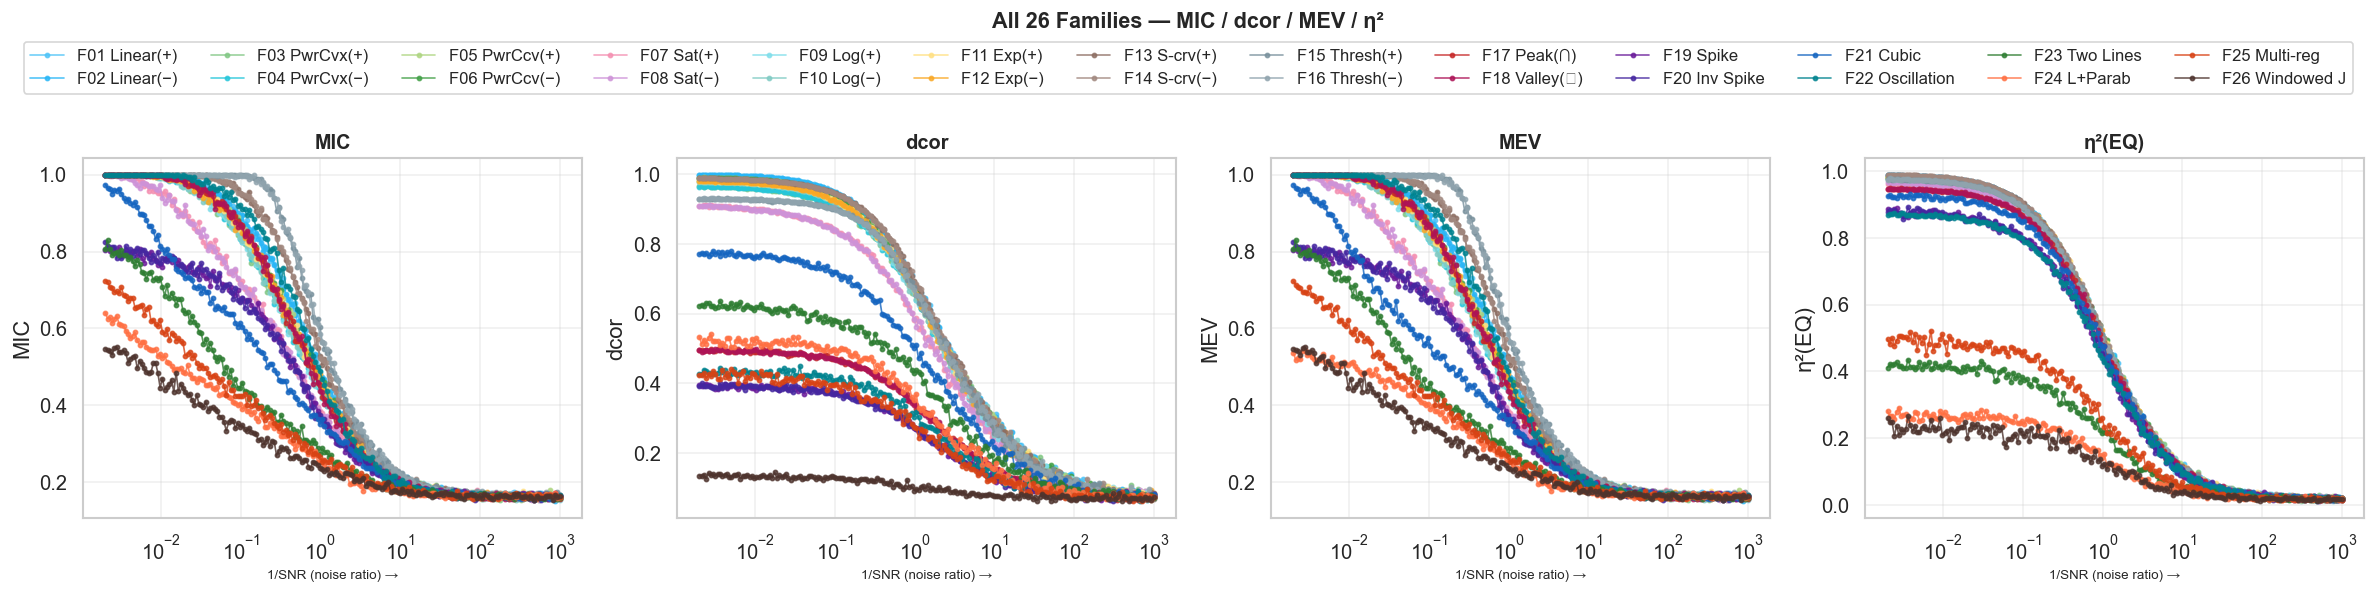


Families with mean metric ≥ 0.8 for ALL SNR ≥ 10

MIC (17 families):
  ✓ F01 (Linear(+))
  ✓ F02 (Linear(−))
  ✓ F03 (PwrCvx(+))
  ✓ F04 (PwrCvx(−))
  ✓ F05 (PwrCcv(+))
  ✓ F06 (PwrCcv(−))
  ✓ F09 (Log(+))
  ✓ F10 (Log(−))
  ✓ F11 (Exp(+))
  ✓ F12 (Exp(−))
  ✓ F13 (S-crv(+))
  ✓ F14 (S-crv(−))
  ✓ F15 (Thresh(+))
  ✓ F16 (Thresh(−))
  ✓ F17 (Peak(∩))
  ✓ F18 (Valley(∪))
  ✓ F22 (Oscillation)

dcor (16 families):
  ✓ F01 (Linear(+))
  ✓ F02 (Linear(−))
  ✓ F03 (PwrCvx(+))
  ✓ F04 (PwrCvx(−))
  ✓ F05 (PwrCcv(+))
  ✓ F06 (PwrCcv(−))
  ✓ F07 (Sat(+))
  ✓ F08 (Sat(−))
  ✓ F09 (Log(+))
  ✓ F10 (Log(−))
  ✓ F11 (Exp(+))
  ✓ F12 (Exp(−))
  ✓ F13 (S-crv(+))
  ✓ F14 (S-crv(−))
  ✓ F15 (Thresh(+))
  ✓ F16 (Thresh(−))

MEV (17 families):
  ✓ F01 (Linear(+))
  ✓ F02 (Linear(−))
  ✓ F03 (PwrCvx(+))
  ✓ F04 (PwrCvx(−))
  ✓ F05 (PwrCcv(+))
  ✓ F06 (PwrCcv(−))
  ✓ F09 (Log(+))
  ✓ F10 (Log(−))
  ✓ F11 (Exp(+))
  ✓ F12 (Exp(−))
  ✓ F13 (S-crv(+))
  ✓ F14 (S-crv(−))
  ✓ F15 (Thresh(+))
  ✓ F16 (Thresh(−

In [1056]:
# ── Panel D (combined): all 26 families in one plot per metric ──


COMB_METRICS = [
    ('MIC', 'MIC'),
    ('distance_correlation', 'dcor'),
    ('MEV', 'MEV'),
    ('equal_count_bin_eta_squared', 'η²(EQ)'),
]

all_fids = [f'F{i:02d}' for i in range(1, 27)]

fig, axes = plt.subplots(1, len(COMB_METRICS), figsize=(5 * len(COMB_METRICS), 4.5))

for ax, (col, label) in zip(axes, COMB_METRICS):
    for fid in all_fids:
        sub = signal[signal['family_id'] == fid]
        agg = sub.groupby('snr_val')[col].mean().reset_index()
        agg = agg[np.isfinite(agg['snr_val']) & (agg['snr_val'] > 0)].copy()
        agg['noise_ratio'] = 1.0 / agg['snr_val']
        agg = agg.sort_values('noise_ratio')
        ax.plot(agg['noise_ratio'], agg[col], '-o',
                color=FAMILY_PALETTE[fid],
                markersize=2.5, linewidth=1.0, alpha=0.8,
                label=f'{fid} {SHORT.get(fid, "")}')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('1/SNR (noise ratio) →', fontsize=8)
    ax.set_ylabel(label)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=13,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, 1.06))
fig.suptitle('All 26 Families — MIC / dcor / MEV / η²',
             fontsize=13, fontweight='bold', y=1.10)
plt.tight_layout()
plt.show()

# ── Print families with metric ≥ 0.8 across SNR ∈ [10, ∞) ──
print('\n' + '='*70)
print('Families with mean metric ≥ 0.8 for ALL SNR ≥ 10')
print('='*70)
for col, label in COMB_METRICS:
    qualified = []
    for fid in all_fids:
        sub = signal[signal['family_id'] == fid]
        agg = sub.groupby('snr_val')[col].mean().reset_index()
        high_snr = agg[agg['snr_val'] >= 10]
        if len(high_snr) > 0 and high_snr[col].min() >= 0.8:
            qualified.append(f'{fid} ({SHORT[fid]})')
    print(f'\n{label} ({len(qualified)} families):')
    for q in qualified:
        print(f'  ✓ {q}')


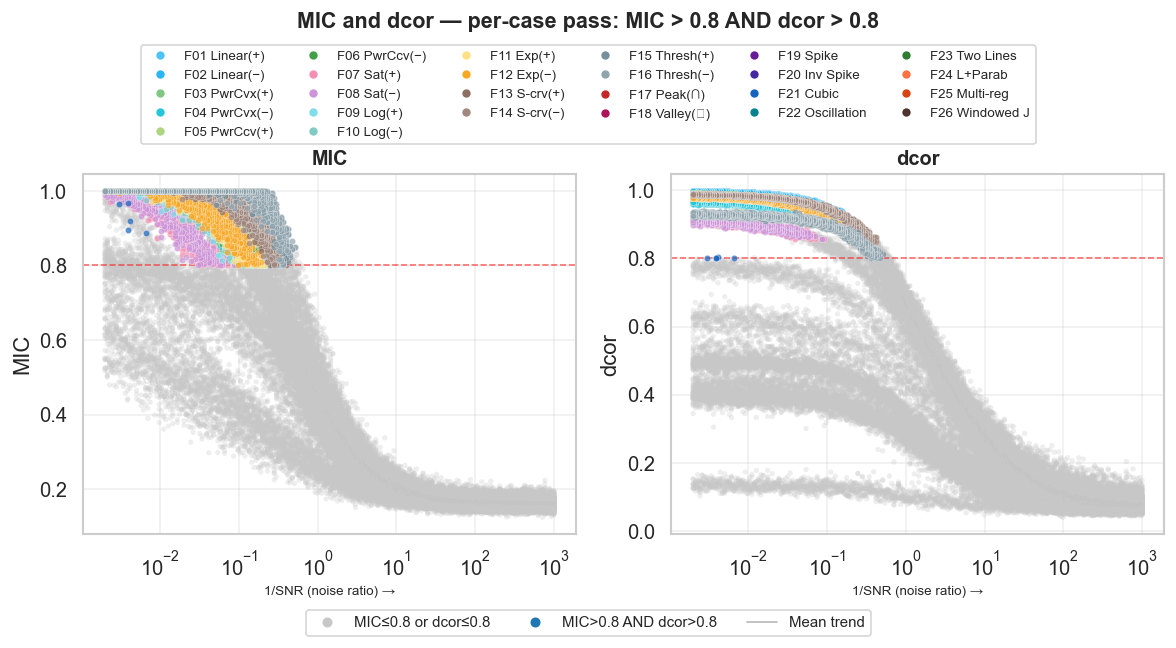

In [1057]:
# ── Panel D variant: highlight family/SNR points passing MIC > 0.8 AND dcor > 0.8 ──
# Per-case 判定: 每个 case 独立判断是否 MIC > thresh AND dcor > thresh
# 图: 线 = 每个 family 的 mean 趋势; 散点 = per-case, 通过上色 / 不通过灰色

MIC_PASS_THRESH = 0.8
DCOR_PASS_THRESH = 0.8
HIGHLIGHT_METRICS = [
    ('MIC', 'MIC'),
    ('distance_correlation', 'dcor'),
]

# Per-case pass flag
signal['_dual_pass'] = (signal['MIC'] > MIC_PASS_THRESH) & \
                       (signal['distance_correlation'] > DCOR_PASS_THRESH)

fig, axes = plt.subplots(1, len(HIGHLIGHT_METRICS), figsize=(5 * len(HIGHLIGHT_METRICS), 4.5))
axes = np.atleast_1d(axes)

for ax, (col, label) in zip(axes, HIGHLIGHT_METRICS):
    for fid in all_fids:
        sub = signal[signal['family_id'] == fid].copy()
        sub = sub[np.isfinite(sub['snr_val']) & (sub['snr_val'] > 0)].copy()
        if len(sub) == 0:
            continue
        sub['noise_ratio'] = 1.0 / sub['snr_val']

        # Mean trend line (grey)
        agg = sub.groupby('snr_val').agg(value=(col, 'mean')).reset_index()
        agg['noise_ratio'] = 1.0 / agg['snr_val']
        agg = agg.sort_values('noise_ratio')
        ax.plot(agg['noise_ratio'], agg['value'], '-',
                color='0.72', linewidth=0.8, alpha=0.35, zorder=1)

        # Per-case scatter: pass → family color, fail → grey
        fail = sub[~sub['_dual_pass']]
        passed = sub[sub['_dual_pass']]
        if len(fail) > 0:
            ax.scatter(fail['noise_ratio'], fail[col],
                       color='0.78', s=10, alpha=0.3, edgecolors='none', zorder=2)
        if len(passed) > 0:
            ax.scatter(passed['noise_ratio'], passed[col],
                       color=FAMILY_PALETTE[fid], s=14, alpha=0.7,
                       edgecolors='white', linewidths=0.2, zorder=3)

    ax.axhline(0.8, color='red', linestyle='--', linewidth=1.0, alpha=0.55)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('1/SNR (noise ratio) →', fontsize=8)
    ax.set_ylabel(label)

family_handles = [Line2D([0], [0], color=FAMILY_PALETTE[f], marker='o',
                         markersize=4, linewidth=0,
                         label=f'{f} {SHORT.get(f, "")}') for f in all_fids]
status_handles = [
    Line2D([0], [0], color='0.78', marker='o', markersize=5, linewidth=0,
           label=f'MIC≤{MIC_PASS_THRESH} or dcor≤{DCOR_PASS_THRESH}'),
    Line2D([0], [0], color='tab:blue', marker='o', markersize=5, linewidth=0,
           label=f'MIC>{MIC_PASS_THRESH} AND dcor>{DCOR_PASS_THRESH}'),
    Line2D([0], [0], color='0.72', linewidth=1.0,
           label='Mean trend'),
]
fig.legend(handles=family_handles, loc='upper center', ncol=6,
           fontsize=8, frameon=True, bbox_to_anchor=(0.5, 1.08))
fig.legend(handles=status_handles, loc='lower center', ncol=3,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(f'MIC and dcor — per-case pass: MIC > {MIC_PASS_THRESH} AND dcor > {DCOR_PASS_THRESH}',
             fontsize=13, fontweight='bold', y=1.13)
plt.tight_layout()
plt.show()

signal.drop(columns='_dual_pass', inplace=True)


In [1058]:
# # ── Panel D (combined, filtered): families with most points ≥ 0.8 ──

# THRESH = 0.8
# FRAC_ABOVE = 0.5

# fig, axes = plt.subplots(1, len(COMB_METRICS), figsize=(5 * len(COMB_METRICS), 4.5))

# legend_fids = set()

# for ax, (col, label) in zip(axes, COMB_METRICS):
#     for fid in all_fids:
#         sub = signal[signal['family_id'] == fid]
#         agg = sub.groupby('snr_val')[col].mean().reset_index()
#         agg = agg[np.isfinite(agg['snr_val']) & (agg['snr_val'] > 0)].copy()
#         agg['noise_ratio'] = 1.0 / agg['snr_val']
#         check = agg[agg['snr_val'] >= 1]
#         if len(check) == 0:
#             continue
#         frac = (check[col] >= THRESH).mean()
#         if frac < FRAC_ABOVE:
#             continue
#         legend_fids.add(fid)
#         agg = agg.sort_values('noise_ratio')
#         ax.plot(agg['noise_ratio'], agg[col], '-o',
#                 color=FAMILY_PALETTE[fid],
#                 markersize=2.5, linewidth=1.0, alpha=0.85,
#                 label=f'{fid} {SHORT.get(fid, "")}')
#     ax.axhline(THRESH, color='red', linestyle='--', linewidth=1.0, alpha=0.6)
#     ax.set_xscale('log')
#     ax.grid(True, alpha=0.3)
#     ax.set_title(label, fontweight='bold', fontsize=12)
#     ax.set_xlabel('1/SNR (noise ratio) →', fontsize=8)
#     ax.set_ylabel(label)

# legend_order = [f for f in all_fids if f in legend_fids]
# from matplotlib.lines import Line2D
# handles = [Line2D([0], [0], color=FAMILY_PALETTE[f], marker='o',
#                   markersize=4, linewidth=1.2,
#                   label=f'{f} {SHORT.get(f, "")}') for f in legend_order]
# fig.legend(handles=handles, loc='upper center', ncol=13,
#            fontsize=10, frameon=True, bbox_to_anchor=(0.5, 1.06))
# fig.suptitle(f'Families with ≥ {int(FRAC_ABOVE*100)}% Points Above {THRESH} (SNR ≥ 1)',
#              fontsize=13, fontweight='bold', y=1.10)
# plt.tight_layout()
# plt.show()

# # ── Summary table: % of SNR levels (≥ 1) where metric ≥ 0.8 ──
# rows = []
# for fid in all_fids:
#     row = {'fid': fid, 'name': SHORT[fid]}
#     for col, label in COMB_METRICS:
#         sub = signal[signal['family_id'] == fid]
#         agg = sub.groupby('snr_val')[col].mean().reset_index()
#         high = agg[agg['snr_val'] >= 1]
#         if len(high) == 0:
#             row[label] = 0.0
#         else:
#             row[label] = (high[col] >= THRESH).mean()
#     rows.append(row)

# tbl = pd.DataFrame(rows)
# metric_cols = [label for _, label in COMB_METRICS]
# tbl['avg'] = tbl[metric_cols].mean(axis=1)
# tbl = tbl.sort_values('avg', ascending=False).reset_index(drop=True)

# print(f'% of SNR levels (∞ → 1) where mean metric ≥ {THRESH}')
# print(f'(families with avg ≥ {int(FRAC_ABOVE*100)}% are shown in plot above)\n')
# header = f'{"Rank":>4}  {"Family":<28} ' + '  '.join(f'{c:>6}' for c in metric_cols) + f'  {"avg":>6}'
# print(header)
# print('─' * len(header))
# for i, r in tbl.iterrows():
#     mark = '★' if r['avg'] >= FRAC_ABOVE else ' '
#     line = f'{i+1:>3}{mark}  {r["fid"] + " " + r["name"]:<28} '
#     line += '  '.join(f'{r[c]:>5.0%}' for c in metric_cols)
#     line += f'  {r["avg"]:>5.0%}'
#     print(line)


# # ── Export table to CSV ──
# tbl.to_csv('output/S2/metric_above_08_summary.csv', index=False)
# print(f'\nSaved to output/S2/metric_above_08_summary.csv')



In [1059]:
# # ── Scatterplots at metric ≈ 0.8 for qualifying families ──

# pts = np.load('output/S1/scatter_points.npz')
# X_all, Y_all = pts['x'], pts['y']
# cases_df = pd.read_csv('output/S1/cases.csv', low_memory=False)
# cases_df['snr_f'] = cases_df['snr'].apply(lambda x: float('inf') if str(x)=='inf' else float(x))

# THRESH = 0.8
# FRAC_ABOVE = 0.5

# for col, label in COMB_METRICS:
#     qual_fids = []
#     for fid in all_fids:
#         sub = signal[signal['family_id'] == fid]
#         agg = sub.groupby('snr_val')[col].mean().reset_index()
#         high = agg[agg['snr_val'] >= 1]
#         if len(high) == 0:
#             continue
#         frac = (high[col] >= THRESH).mean()
#         if frac >= FRAC_ABOVE:
#             qual_fids.append(fid)

#     n = len(qual_fids)
#     if n == 0:
#         continue
#     ncols_g = min(6, n)
#     nrows_g = math.ceil(n / ncols_g)
#     fig, axes = plt.subplots(nrows_g, ncols_g, figsize=(3 * ncols_g, 3 * nrows_g))
#     if nrows_g * ncols_g == 1:
#         axes = np.array([axes])
#     axes = np.atleast_2d(axes).reshape(nrows_g, ncols_g)

#     for idx, fid in enumerate(qual_fids):
#         r, c = divmod(idx, ncols_g)
#         ax = axes[r, c]

#         # Find the SNR level where mean metric is closest to 0.8
#         sub = signal[signal['family_id'] == fid]
#         agg = sub.groupby('snr_val')[col].mean().reset_index()
#         agg = agg[np.isfinite(agg['snr_val'])].copy()
#         agg['diff'] = (agg[col] - THRESH).abs()
#         best_snr = agg.loc[agg['diff'].idxmin(), 'snr_val']
#         best_metric = agg.loc[agg['diff'].idxmin(), col]

#         # Pick replicate 0 at that SNR
#         fam_cases = cases_df[(cases_df['family_id'] == fid) &
#                             (np.isclose(cases_df['snr_f'], best_snr, rtol=1e-6)) &
#                             (cases_df['replicate'] == 0)]
#         if len(fam_cases) == 0:
#             fam_cases = cases_df[(cases_df['family_id'] == fid) &
#                                 (np.isclose(cases_df['snr_f'], best_snr, rtol=1e-3))].head(1)
#         if len(fam_cases) == 0:
#             ax.set_visible(False)
#             continue
#         ci = fam_cases.index[0]
#         ax.scatter(X_all[ci], Y_all[ci], s=4, alpha=0.5,
#                    color=FAMILY_PALETTE[fid], edgecolors='none')
#         ax.set_title(f'{fid} {SHORT[fid]}\n{label}={best_metric:.2f}  SNR={best_snr:.1f}',
#                      fontsize=8, fontweight='bold', color=FAMILY_PALETTE[fid])
#         ax.set_xticks([])
#         ax.set_yticks([])
#         ax.grid(True, alpha=0.2)

#     for idx in range(n, nrows_g * ncols_g):
#         r, c = divmod(idx, ncols_g)
#         axes[r, c].set_visible(False)

#     fig.suptitle(f'{label} ≈ {THRESH}: what the data looks like at the threshold  ({n} families)',
#                  fontsize=13, fontweight='bold', y=1.02)
#     plt.tight_layout()
#     plt.show()


In [1060]:
# # ── Scatterplots of qualifying families at SNR=1 and SNR=0.1 ──

# TARGET_SNRS = [1.0, 0.1]

# # Collect all qualifying families (union across 4 metrics)
# qual_union = set()
# for col, label in COMB_METRICS:
#     for fid in all_fids:
#         sub = signal[signal['family_id'] == fid]
#         agg = sub.groupby('snr_val')[col].mean().reset_index()
#         high = agg[agg['snr_val'] >= 1]
#         if len(high) == 0:
#             continue
#         frac = (high[col] >= THRESH).mean()
#         if frac >= FRAC_ABOVE:
#             qual_union.add(fid)
# qual_fids = sorted(qual_union)
# n = len(qual_fids)

# for target_snr in TARGET_SNRS:
#     ncols_g = min(6, n)
#     nrows_g = math.ceil(n / ncols_g)
#     fig, axes = plt.subplots(nrows_g, ncols_g, figsize=(3 * ncols_g, 3 * nrows_g))
#     if nrows_g * ncols_g == 1:
#         axes = np.array([axes])
#     axes = np.atleast_2d(axes).reshape(nrows_g, ncols_g)

#     for idx, fid in enumerate(qual_fids):
#         r, c = divmod(idx, ncols_g)
#         ax = axes[r, c]

#         # Find the closest SNR to target
#         fam_cases = cases_df[cases_df['family_id'] == fid].copy()
#         fam_cases['snr_diff'] = (fam_cases['snr_f'] - target_snr).abs()
#         closest_snr = fam_cases.loc[fam_cases['snr_diff'].idxmin(), 'snr_f']
#         pick = fam_cases[(np.isclose(fam_cases['snr_f'], closest_snr, rtol=1e-6)) &
#                         (fam_cases['replicate'] == 0)]
#         if len(pick) == 0:
#             pick = fam_cases[np.isclose(fam_cases['snr_f'], closest_snr, rtol=1e-6)].head(1)
#         if len(pick) == 0:
#             ax.set_visible(False)
#             continue
#         ci = pick.index[0]
#         ax.scatter(X_all[ci], Y_all[ci], s=4, alpha=0.5,
#                    color=FAMILY_PALETTE[fid], edgecolors='none')
#         ax.set_title(f'{fid} {SHORT[fid]}', fontsize=9, fontweight='bold',
#                      color=FAMILY_PALETTE[fid])
#         ax.set_xticks([])
#         ax.set_yticks([])
#         ax.grid(True, alpha=0.2)

#     for idx in range(n, nrows_g * ncols_g):
#         r, c = divmod(idx, ncols_g)
#         axes[r, c].set_visible(False)

#     fig.suptitle(f'Qualifying families at SNR = {target_snr}  (1/SNR = {1/target_snr:g})',
#                  fontsize=13, fontweight='bold', y=1.02)
#     plt.tight_layout()
#     plt.show()


In [1061]:
# # ── Panel D (heatmap): families × 1/SNR — metric ≥ 0.8 indicator ──

# HEAT_METRICS = [
#     ('MIC', 'MIC'),
#     ('distance_correlation', 'dcor'),
#     ('MEV', 'MEV'),
#     ('equal_count_bin_eta_squared', 'η²(EQ)'),
# ]

# all_fids = [f'F{i:02d}' for i in range(1, 27)]

# SHORT_H = {
#     'F01': 'Linear(+)',     'F02': 'Linear(−)',     'F03': 'PwrCvx(+)',
#     'F04': 'PwrCvx(−)',    'F05': 'PwrCcv(+)',     'F06': 'PwrCcv(−)',
#     'F07': 'Sat(+)',        'F08': 'Sat(−)',        'F09': 'Log(+)',
#     'F10': 'Log(−)',        'F11': 'Exp(+)',        'F12': 'Exp(−)',
#     'F13': 'S-crv(+)',      'F14': 'S-crv(−)',      'F15': 'Thresh(+)',
#     'F16': 'Thresh(−)',     'F17': 'Peak(∩)',       'F18': 'Valley(∪)',
#     'F19': 'Spike',         'F20': 'Inv Spike',     'F21': 'Cubic',
#     'F22': 'Oscillation',       'F23': 'Two Lines',     'F24': 'L+Parab',
#     'F25': 'Multi-reg',     'F26': 'Windowed J',
# }

# sig = signal[np.isfinite(signal['snr_val']) & (signal['snr_val'] > 0)].copy()
# sig['noise_ratio'] = 1.0 / sig['snr_val']
# nr_levels = sorted(sig['noise_ratio'].unique())

# from matplotlib.colors import LinearSegmentedColormap
# cmap_bin = LinearSegmentedColormap.from_list('bin08', ['#F5F5F5', '#43A047'], N=256)

# fig, axes = plt.subplots(1, len(HEAT_METRICS), figsize=(6 * len(HEAT_METRICS), 7))

# for ax, (col, label) in zip(axes, HEAT_METRICS):
#     mat = np.full((len(all_fids), len(nr_levels)), np.nan)
#     for i, fid in enumerate(all_fids):
#         sub = sig[sig['family_id'] == fid]
#         agg = sub.groupby('noise_ratio')[col].mean()
#         for j, nr in enumerate(nr_levels):
#             if nr in agg.index:
#                 mat[i, j] = agg[nr]

#     im = ax.imshow(mat, aspect='auto', vmin=0, vmax=1, cmap=cmap_bin,
#                    interpolation='nearest')

#     for i in range(len(all_fids)):
#         row = mat[i]
#         for j in range(len(nr_levels) - 1):
#             if (row[j] >= 0.8 and row[j+1] < 0.8) or (row[j] < 0.8 and row[j+1] >= 0.8):
#                 ax.axvline(j + 0.5, ymin=(len(all_fids) - i - 1.5) / len(all_fids),
#                            ymax=(len(all_fids) - i - 0.5) / len(all_fids),
#                            color='red', linewidth=0.3, alpha=0.4)

#     tick_nrs = [0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.5, 1.0]
#     tick_pos = []
#     tick_lab = []
#     for tn in tick_nrs:
#         closest = min(range(len(nr_levels)), key=lambda j: abs(nr_levels[j] - tn))
#         tick_pos.append(closest)
#         tick_lab.append(f'{tn:g}')
#     ax.set_xticks(tick_pos)
#     ax.set_xticklabels(tick_lab, fontsize=7)
#     ax.set_xlabel('1/SNR (noise ratio)', fontsize=9)

#     ax.set_yticks(range(len(all_fids)))
#     ax.set_yticklabels([f'{f} {SHORT_H[f]}' for f in all_fids], fontsize=7)
#     ax.set_title(label, fontweight='bold', fontsize=12)

#     cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
#     cbar.ax.axhline(0.8, color='red', linewidth=1.5, linestyle='--')
#     cbar.ax.tick_params(labelsize=7)

# fig.suptitle('Metric Value by Family × 1/SNR (green ≥ 0.8, red dashed = 0.8 threshold)',
#              fontsize=12, fontweight='bold', y=1.02)
# plt.tight_layout()
# plt.show()


## Panel E — MCN by Family Group

In [1062]:
# # ── Panel E: MCN split by family group ──

# group1 = [f'F{i:02d}' for i in range(1, 13)]
# group2 = [f'F{i:02d}' for i in range(13, 27)]
# groups = [
#     (group1, 'F01–F12  (simple shapes)'),
#     (group2, 'F13–F26  (complex / multi-branch)'),
# ]

# fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# for ax, (fids, grp_label) in zip(axes, groups):
#     for fid in fids:
#         sub = signal[signal['family_id'] == fid]
#         agg = sub.groupby('snr_val')['MCN'].mean().reset_index()
#         agg = agg[np.isfinite(agg['snr_val']) & (agg['snr_val'] > 0)].copy()
#         agg['noise_ratio'] = 1.0 / agg['snr_val']
#         agg = agg.sort_values('noise_ratio')
#         ax.plot(agg['noise_ratio'], agg['MCN'], '-o',
#                 color=FAMILY_PALETTE[fid],
#                 markersize=3, linewidth=1.2, alpha=0.85,
#                 label=fid)
#     ax.set_xscale('log')
#     ax.grid(True, alpha=0.3)
#     ax.set_title(f'MCN — {grp_label}', fontweight='bold', fontsize=11)
#     ax.set_xlabel('1/SNR (noise ratio) →', fontsize=8)
#     ax.set_ylabel('MCN')
#     ax.legend(fontsize=7, ncol=2, loc='best', framealpha=0.8, handlelength=1.5)

# plt.tight_layout()
# plt.show()


In [1063]:
# ── SNR=∞ baseline: 26 families + Null 的 MIC / dcor (无噪声) ──
# 检查哪些函数在完全没有噪声时，MIC 和 dcor 仍然不高

_all_cases = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
_all_metrics = pd.read_parquet(S2_DIR / 'metrics_full.parquet')
_inf = _all_metrics.merge(
    _all_cases[['case_id','family_id','family_name','variant_level','snr']],
    on='case_id'
)
_inf['snr_val'] = _inf['snr'].apply(lambda x: float('inf') if str(x) == 'inf' else float(x))
_inf = _inf[(_inf['snr_val'] == float('inf')) & _inf['variant_level'].isin(['strong', 'none'])].copy()

MIC_TH, DCOR_TH = 0.8, 0.8

print('═══ SNR=∞ (zero noise) baseline: MIC & dcor per family ═══')
print(f'Threshold: MIC ≥ {MIC_TH}  AND  dcor ≥ {DCOR_TH}')
print()

hdr = f'{"Family":<6} {"Name":<18} {"MIC":>6} {"dcor":>6} {"|r|":>6} {"|ρ|":>6} {"MAS":>6} {"Pass?":<10}'
sep = '─' * len(hdr)

fids = sorted(_inf['family_id'].unique(), key=lambda x: (x != 'Null', x))
fids = [f for f in fids if f != 'Null'] + (['Null'] if 'Null' in fids else [])

pass_both = []
pass_mic_only = []
fail_both = []
rows = []

for fid in fids:
    sub = _inf[_inf['family_id'] == fid]
    mic_m  = sub['MIC'].mean()
    dcor_m = sub['distance_correlation'].mean()
    r_m    = sub['pearson_r'].abs().mean()
    rho_m  = sub['spearman_rho'].abs().mean()
    mas_m  = sub['MAS'].mean()
    name   = sub.iloc[0]['family_name'][:18]

    mic_ok  = mic_m >= MIC_TH
    dcor_ok = dcor_m >= DCOR_TH

    if mic_ok and dcor_ok:
        tag = '✓ Both'
        pass_both.append(fid)
    elif mic_ok:
        tag = '△ MIC'
        pass_mic_only.append(fid)
    else:
        tag = '✗ Neither'
        fail_both.append(fid)

    rows.append(f'{fid:<6} {name:<18} {mic_m:>6.3f} {dcor_m:>6.3f} {r_m:>6.3f} {rho_m:>6.3f} {mas_m:>6.3f} {tag:<10}')

mid = (len(rows) + 1) // 2
col_w = len(hdr)
print(f'{hdr:<{col_w}}  {hdr}')
print(f'{sep}  {sep}')
for i in range(mid):
    left = rows[i]
    right = rows[i + mid] if i + mid < len(rows) else ''
    print(f'{left:<{col_w}}  {right}')

print()
print(f'── Summary (at SNR=∞, strong variant) ──')
print(f'  ✓ MIC≥{MIC_TH} AND dcor≥{DCOR_TH}:  {len(pass_both):>2} families  {pass_both}')
print(f'  △ MIC≥{MIC_TH} but dcor<{DCOR_TH}: {len(pass_mic_only):>2} families  {pass_mic_only}')
print(f'  ✗ MIC<{MIC_TH}:               {len(fail_both):>2} families  {fail_both}')
print()
print('△ = detectable by MIC but invisible to dcor (symmetric / multi-segment / oscillatory)')
print('✗ = undetectable even by MIC (too sparse or too localized)')

del _all_cases, _all_metrics, _inf


═══ SNR=∞ (zero noise) baseline: MIC & dcor per family ═══
Threshold: MIC ≥ 0.8  AND  dcor ≥ 0.8

Family Name                  MIC   dcor    |r|    |ρ|    MAS Pass?       Family Name                  MIC   dcor    |r|    |ρ|    MAS Pass?     
───────────────────────────────────────────────────────────────────────  ───────────────────────────────────────────────────────────────────────
F01    Linear positive     1.000  1.000  1.000  1.000  0.000 ✓ Both      F15    Threshold positive  1.000  0.897  0.874  0.784  0.015 ✓ Both    
F02    Linear negative     1.000  1.000  1.000  1.000  0.000 ✓ Both      F16    Threshold negative  0.999  0.903  0.881  0.777  0.000 ✓ Both    
F03    Power convex posit  1.000  0.917  0.868  1.000  0.000 ✓ Both      F17    Quadratic peak (In  1.000  0.496  0.046  0.045  0.670 △ MIC     
F04    Power convex negat  1.000  0.916  0.866  1.000  0.000 ✓ Both      F18    Quadratic valley (  1.000  0.497  0.047  0.060  0.664 △ MIC     
F05    Power concave posi  1.000

## Scheme C — Mean-Response Classification Tree

Simple Path: L2 → Direction → Monotonicity → Linearity → Line判定 + Curvature

Based on the same logic as D_S2.1, applied to the variant-level filtered data.

In [1064]:
# ── Helper: MIC highlight plot (scatter + mean line) ──
_HUE_MARKERS = {0: 'o', 1: '^', 2: 's', 3: 'D', 4: 'v', 5: 'P'}

def plot_mic_highlight(highlight_cases, title, signal_df=None,
                       hue_col=None, hue_palette=None, color_mode='family'):
    """
    Left: scatter (one point per case).
    Right: mean line (mean MIC per family×SNR, 10 replicates averaged).
    Gray = all signal. Colored = highlight subset.
    """
    if signal_df is None:
        signal_df = signal

    sig = signal_df[np.isfinite(signal_df['snr_val']) & (signal_df['snr_val'] > 0)].copy()
    sig['nr'] = 1.0 / sig['snr_val']
    hi = highlight_cases[np.isfinite(highlight_cases['snr_val']) & (highlight_cases['snr_val'] > 0)].copy()
    hi['nr'] = 1.0 / hi['snr_val']

    fig, axes = plt.subplots(2, 1, figsize=(6, 6))

    for panel_idx, ax in enumerate(axes):
        use_mean = (panel_idx == 1)
        ax.set_title(('Per case (scatter)' if not use_mean else 'Per family×SNR (mean)'),
                     fontsize=9, fontstyle='italic')

        # ── Background gray ──
        if use_mean:
            for fid in sorted(sig['family_id'].unique()):
                agg = sig[sig['family_id'] == fid].groupby('snr_val').agg(
                    value=('MIC','mean')).reset_index()
                agg = agg[agg['snr_val'] > 0].copy()
                agg['nr'] = 1.0 / agg['snr_val']
                agg = agg.sort_values('nr')
                ax.plot(agg['nr'], agg['value'], '-', color='0.85', linewidth=0.5, alpha=0.4, zorder=1)
                ax.scatter(agg['nr'], agg['value'], color='0.85', s=6, alpha=0.3, edgecolors='none', zorder=1)
        else:
            ax.scatter(sig['nr'], sig['MIC'], color='0.85', s=3, alpha=0.12, edgecolors='none', zorder=1)

        # ── Highlight ──
        if hue_col and hue_palette:
            hue_vals = list(hue_palette.keys())
            hue_marker = {v: _HUE_MARKERS.get(i, 'o') for i, v in enumerate(hue_vals)}

            if color_mode == 'family':
                for fid in sorted(hi['family_id'].unique()):
                    fcolor = FAMILY_PALETTE.get(fid, '#333')
                    fsub = hi[hi['family_id'] == fid]
                    for hv in hue_vals:
                        hsub = fsub[fsub[hue_col] == hv]
                        if len(hsub) == 0:
                            continue
                        if use_mean:
                            agg = hsub.groupby('snr_val').agg(value=('MIC','mean')).reset_index()
                            agg = agg[agg['snr_val'] > 0].copy()
                            agg['nr'] = 1.0 / agg['snr_val']
                            agg = agg.sort_values('nr')
                            ax.plot(agg['nr'], agg['value'], '-', color=fcolor, linewidth=0.8, alpha=0.7, zorder=2)
                            ax.scatter(agg['nr'], agg['value'], color=fcolor, marker=hue_marker[hv],
                                       s=14, alpha=0.8, edgecolors='white', linewidths=0.2, zorder=3)
                        else:
                            ax.scatter(hsub['nr'], hsub['MIC'], color=fcolor, marker=hue_marker[hv],
                                       s=8, alpha=0.45, edgecolors='none', zorder=3)

                if panel_idx == 0:
                    fam_handles = [Line2D([0],[0], color=FAMILY_PALETTE.get(f,'#333'), marker='o',
                                          markersize=5, linewidth=0, label=f'{f} {SHORT.get(f,"")}')
                                   for f in sorted(hi['family_id'].unique())]
                    hue_handles = [Line2D([0],[0], color='0.3', marker=hue_marker[hv], markersize=6,
                                          linewidth=0, label=hv) for hv in hue_vals]
                    leg1 = ax.legend(handles=fam_handles, fontsize=7, ncol=2,
                                     loc='upper right', title='Family', title_fontsize=6)
                    ax.add_artist(leg1)
                    ax.legend(handles=hue_handles, fontsize=7, loc='lower right',
                              title=hue_col, title_fontsize=7)

            elif color_mode == 'hue':
                for hv in hue_vals:
                    hcolor = hue_palette[hv]
                    hsub = hi[hi[hue_col] == hv]
                    if len(hsub) == 0:
                        continue
                    if use_mean:
                        for fid in sorted(hsub['family_id'].unique()):
                            agg = hsub[hsub['family_id'] == fid].groupby('snr_val').agg(
                                value=('MIC','mean')).reset_index()
                            agg = agg[agg['snr_val'] > 0].copy()
                            agg['nr'] = 1.0 / agg['snr_val']
                            agg = agg.sort_values('nr')
                            ax.plot(agg['nr'], agg['value'], '-', color=hcolor, linewidth=0.8, alpha=0.7, zorder=2)
                            ax.scatter(agg['nr'], agg['value'], color=hcolor, s=12, alpha=0.8,
                                       edgecolors='white', linewidths=0.2, zorder=3)
                    else:
                        ax.scatter(hsub['nr'], hsub['MIC'], color=hcolor,
                                   s=6, alpha=0.4, edgecolors='none', zorder=3)

                if panel_idx == 0:
                    handles = [Line2D([0],[0], color=hue_palette[hv], marker='o',
                                      markersize=6, linewidth=0, label=hv) for hv in hue_vals]
                    ax.legend(handles=handles, fontsize=8, loc='upper right',
                              title=hue_col, title_fontsize=8)
        else:
            for fid in sorted(hi['family_id'].unique()):
                fsub = hi[hi['family_id'] == fid]
                fcolor = FAMILY_PALETTE.get(fid, '#333')
                if use_mean:
                    agg = fsub.groupby('snr_val').agg(value=('MIC','mean')).reset_index()
                    agg = agg[agg['snr_val'] > 0].copy()
                    agg['nr'] = 1.0 / agg['snr_val']
                    agg = agg.sort_values('nr')
                    ax.plot(agg['nr'], agg['value'], '-', color=fcolor, linewidth=1.0, alpha=0.8, zorder=3)
                    ax.scatter(agg['nr'], agg['value'], color=fcolor, s=14, alpha=0.85,
                               edgecolors='white', linewidths=0.2, zorder=3,
                               label=f'{fid} {SHORT.get(fid,"")}')
                else:
                    ax.scatter(fsub['nr'], fsub['MIC'], color=fcolor,
                               s=8, alpha=0.45, edgecolors='none', zorder=3,
                               label=f'{fid} {SHORT.get(fid,"")}')
            if panel_idx == 0:
                ax.legend(fontsize=6, ncol=2, loc='upper right')

        ax.axhline(0.8, color='red', linestyle='--', linewidth=0.8, alpha=0.4)
        ax.set_xscale('log')
        ax.set_xlabel('1/SNR →', fontsize=8)
        ax.set_ylabel('MIC', fontsize=8)
        ax.tick_params(axis='both', labelsize=8)
        ax.grid(True, alpha=0.2)

    fig.suptitle(title, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Helper plot_mic_highlight() defined — left: scatter, right: mean line')


Helper plot_mic_highlight() defined — left: scatter, right: mean line


In [1084]:
# ── Step 1: Global Relationship Filter ──
MIC_THRESH = 0.8
DCOR_THRESH = 0.7

mic_pass  = signal['MIC'] >= MIC_THRESH
dcor_pass = signal['distance_correlation'] >= DCOR_THRESH
both_pass = mic_pass & dcor_pass

filtered_cases = signal[both_pass].copy()

all_fids = sorted(signal['family_id'].unique())
qual_fids = sorted(filtered_cases['family_id'].unique())
excl_fids = [f for f in all_fids if f not in qual_fids]

active_levels = [l for l in ['strong','standard','mild'] if l in signal['variant_level'].values]

print(f'═══ Step 1: Global Relationship Filter ═══')
print(f'Rule: MIC ≥ {MIC_THRESH} AND dcor ≥ {DCOR_THRESH}  (per case)')
print(f'Variant levels: {active_levels}')
print()
print(f'  MIC ≥ {MIC_THRESH}:  {mic_pass.sum():>7,} / {len(signal):,}  ({mic_pass.mean():.1%})')
print(f'  dcor ≥ {DCOR_THRESH}: {dcor_pass.sum():>7,} / {len(signal):,}  ({dcor_pass.mean():.1%})')
print(f'  Both:     {both_pass.sum():>7,} / {len(signal):,}  ({both_pass.mean():.1%})')
print(f'  Qualifying families: {len(qual_fids)} / {len(all_fids)} — {qual_fids}')
print(f'  Excluded: {excl_fids}')
print()

hdr = f'{"Family":<16} {"MIC≥.8":>12} {"dcor≥.8":>12} {"Both":>12} {"Total":>7}'
sep = '─' * len(hdr)
rows = []
for fid in all_fids:
    sub = signal[signal['family_id'] == fid]
    n = len(sub)
    n_mic  = int((sub['MIC'] >= MIC_THRESH).sum())
    n_dcor = int((sub['distance_correlation'] >= DCOR_THRESH).sum())
    n_both = int(((sub['MIC'] >= MIC_THRESH) & (sub['distance_correlation'] >= DCOR_THRESH)).sum())
    p_mic  = n_mic / n if n > 0 else 0
    p_dcor = n_dcor / n if n > 0 else 0
    p_both = n_both / n if n > 0 else 0
    rows.append(f'{fid} {SHORT[fid]:<10} {n_mic:>5,}({p_mic:>4.0%}) {n_dcor:>5,}({p_dcor:>4.0%}) {n_both:>5,}({p_both:>4.0%}) {n:>7,}')

mid = (len(rows) + 1) // 2
col_w = len(hdr)
print(f'{hdr:<{col_w}}  {hdr}')
print(f'{sep}  {sep}')
for i in range(mid):
    left = rows[i]
    right = rows[i + mid] if i + mid < len(rows) else ''
    print(f'{left:<{col_w}}  {right}')


═══ Step 1: Global Relationship Filter ═══
Rule: MIC ≥ 0.8 AND dcor ≥ 0.7  (per case)
Variant levels: ['standard']

  MIC ≥ 0.8:   13,777 / 52,260  (26.4%)
  dcor ≥ 0.7:  15,401 / 52,260  (29.5%)
  Both:      11,285 / 52,260  (21.6%)
  Qualifying families: 17 / 26 — ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F21']
  Excluded: ['F17', 'F18', 'F19', 'F20', 'F22', 'F23', 'F24', 'F25', 'F26']

Family                 MIC≥.8      dcor≥.8         Both   Total  Family                 MIC≥.8      dcor≥.8         Both   Total
───────────────────────────────────────────────────────────────  ───────────────────────────────────────────────────────────────
F01 Linear(+)    718( 36%)   951( 47%)   718( 36%)   2,010       F14 S-crv(−)     796( 40%)   956( 48%)   796( 40%)   2,010
F02 Linear(−)    725( 36%)   942( 47%)   725( 36%)   2,010       F15 Thresh(+)    848( 42%)   928( 46%)   848( 42%)   2,010
F03 PwrCvx(+)    645( 32%)   9

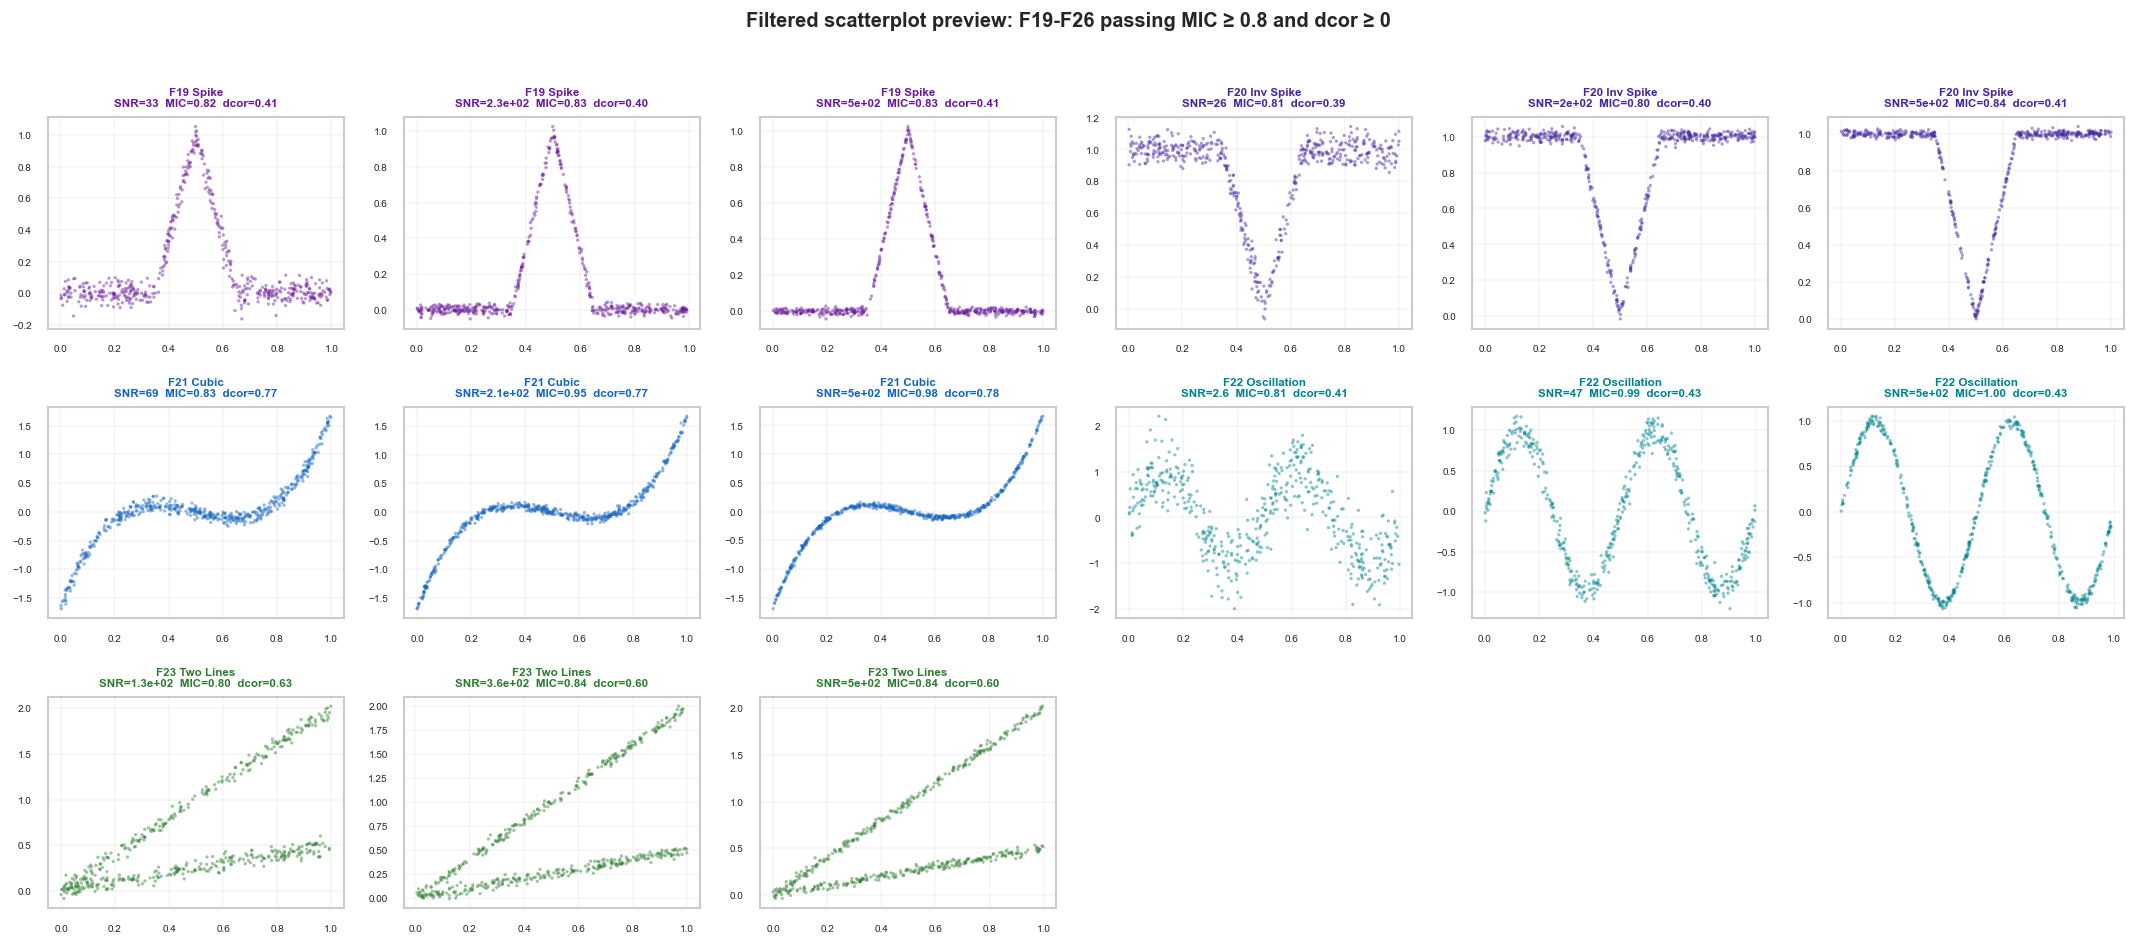

Showing 15 filtered cases from F19-F26 (up to 3 per family).


,case_id,family_id,variant_level,snr_val,MIC,distance_correlation,pearson_r,spearman_rho
0,112135,F19,standard,33.481920,0.817123,0.414996,-0.016168,0.000314
1,112426,F19,standard,226.627977,0.831053,0.396299,0.033428,0.033438
2,112550,F19,standard,500.000000,0.830442,0.414718,-0.026880,-0.024928
3,118128,F20,standard,25.719244,0.814009,0.386966,-0.004619,-0.038136
4,118436,F20,standard,198.626615,0.801568,0.398838,0.036693,0.055320
5,118580,F20,standard,500.000000,0.837169,0.406376,0.031583,0.074639
6,124302,F21,standard,69.155830,0.827781,0.767325,0.796857,0.696993
7,124472,F21,standard,212.165850,0.952168,0.765602,0.797051,0.669624
8,124610,F21,standard,500.000000,0.979922,0.779109,0.801173,0.700550
9,129833,F22,standard,2.558155,0.810257,0.408978,-0.368459,-0.363173


In [1066]:
# ── Preview: scatterplots of filtered cases for F19–F26 ──

PREVIEW_FIDS = [f'F{i:02d}' for i in range(19, 27)]
N_SHOW_PER_FAMILY = 3

pts = np.load(S1_DIR / 'scatter_points.npz')
X_all, Y_all = pts['x'], pts['y']
# Important: scatter_points.npz follows the full S1 cases.csv order, not the variant-filtered cases dataframe.
_cases_full_for_points = pd.read_csv(S1_DIR / 'cases.csv', usecols=['case_id'])
_case_idx_by_id = pd.Series(np.arange(len(_cases_full_for_points)), index=_cases_full_for_points['case_id']).to_dict()

preview_rows = []
for fid in PREVIEW_FIDS:
    sub = filtered_cases[filtered_cases['family_id'] == fid].copy()
    sub = sub[np.isfinite(sub['snr_val']) & (sub['snr_val'] > 0)].copy()
    if len(sub) == 0:
        continue

    # Show representative passed cases across the available noise range.
    sub = sub.sort_values('snr_val')
    if len(sub) <= N_SHOW_PER_FAMILY:
        picks = sub
    else:
        pick_positions = np.linspace(0, len(sub) - 1, N_SHOW_PER_FAMILY).round().astype(int)
        picks = sub.iloc[pick_positions].drop_duplicates('case_id')
    preview_rows.append(picks)

if len(preview_rows) == 0:
    print('No filtered F19-F26 cases to preview.')
else:
    preview_cases = pd.concat(preview_rows, ignore_index=True)
    n = len(preview_cases)
    ncols = 6
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 2.6 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax, (_, row) in zip(axes, preview_cases.iterrows()):
        cid = int(row['case_id'])
        fid = row['family_id']
        idx = _case_idx_by_id.get(cid)
        if idx is None:
            ax.set_visible(False)
            continue

        x = X_all[idx]
        y = Y_all[idx]
        ax.scatter(x, y, s=4, alpha=0.45,
                   color=FAMILY_PALETTE.get(fid, '#333'), edgecolors='none')
        ax.set_title(
            f'{fid} {SHORT.get(fid, "")}\n'
            f'SNR={row["snr_val"]:.2g}  MIC={row["MIC"]:.2f}  dcor={row["distance_correlation"]:.2f}',
            fontsize=7,
            fontweight='bold',
            color=FAMILY_PALETTE.get(fid, '#333'),
        )
        ax.tick_params(labelsize=6)
        ax.grid(True, alpha=0.18)

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle(f'Filtered scatterplot preview: F19-F26 passing MIC ≥ {MIC_THRESH} and dcor ≥ {DCOR_THRESH}',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    print(f'Showing {len(preview_cases)} filtered cases from F19-F26 '
          f'(up to {N_SHOW_PER_FAMILY} per family).')
    display(preview_cases[['case_id', 'family_id', 'variant_level', 'snr_val',
                           'MIC', 'distance_correlation', 'pearson_r', 'spearman_rho']]
            .sort_values(['family_id', 'snr_val']))


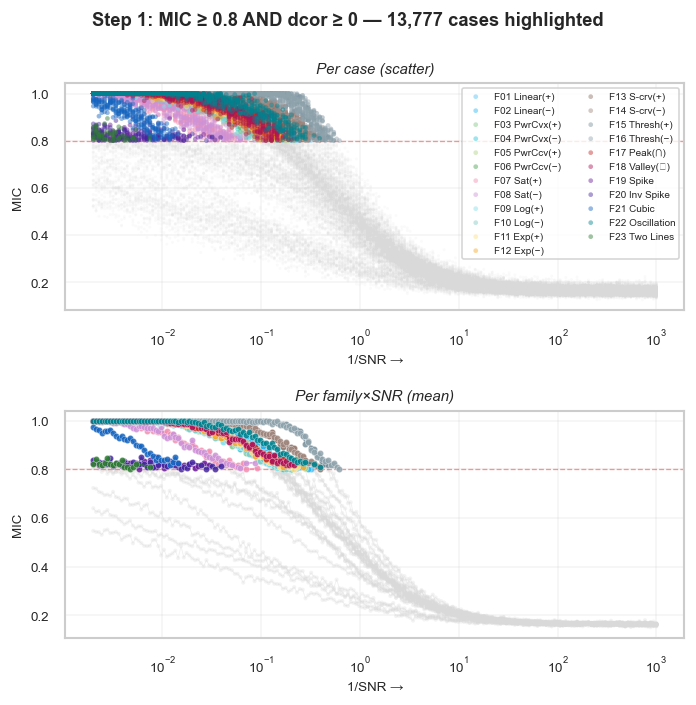

In [1067]:
# ── Step 1 可视化: MIC highlight ──
plot_mic_highlight(filtered_cases, f'Step 1: MIC ≥ {MIC_THRESH} AND dcor ≥ {DCOR_THRESH} — {len(filtered_cases):,} cases highlighted')


In [1068]:
# ── ◇ L2: Simple or Complex? ──
R_THRESH = 0.7
MR_THRESH = 1
REVERSAL_PROMINENCE = 0.1  # 符号反转幅度阈值: |reversed_slope| / max(|E|,|M|,|L|)

sc = filtered_cases.copy()

# ── Base conditions ──
cond_mr  = sc['MIC_minus_r2'] < MR_THRESH
cond_rho = sc['spearman_rho'].abs() >= R_THRESH
cond_r   = sc['pearson_r'].abs() >= R_THRESH

# ── Slope sign reversal check ──
E_s = sc['standardized_polyfit_early_slope'].values
M_s = sc['standardized_polyfit_middle_slope'].values
L_s = sc['standardized_polyfit_late_slope'].values

sign_E = np.sign(E_s)
sign_M = np.sign(M_s)
sign_L = np.sign(L_s)
has_sign_change = ~((sign_E == sign_M) & (sign_M == sign_L))

# Prominence: |reversed_slope| / max(|E|,|M|,|L|)
abs_max = np.maximum(np.maximum(np.abs(E_s), np.abs(M_s)), np.abs(L_s))
abs_max = np.where(abs_max == 0, 1, abs_max)
maj_sign = np.sign(E_s + M_s + L_s)
rev_prom = np.zeros(len(sc))
for i in range(len(sc)):
    if not has_sign_change[i] or maj_sign[i] == 0:
        continue
    slopes_i = [E_s[i], M_s[i], L_s[i]]
    rev_vals = [abs(s) for s in slopes_i if np.sign(s) != maj_sign[i] and np.sign(s) != 0]
    if rev_vals:
        rev_prom[i] = max(rev_vals) / abs_max[i]

sc['reversal_prominence'] = rev_prom
cond_no_turn = pd.Series(~(has_sign_change & (rev_prom >= REVERSAL_PROMINENCE)), index=sc.index)

# ── Combined ──
cond_all = cond_mr & cond_rho & cond_r & cond_no_turn

sc['is_simple'] = cond_all
simple_cases = sc[sc['is_simple']].copy()

n_base = int((cond_mr & cond_rho & cond_r).sum())
n_turned = int((cond_mr & cond_rho & cond_r & ~cond_no_turn).sum())

print(f'═══ Step 2: L2 — Simple or Complex? ═══')
print(f'Rule: MIC-r² < {MR_THRESH} AND |ρ| ≥ {R_THRESH} AND |r| ≥ {R_THRESH}')
print(f'      + no significant slope sign reversal (prominence ≥ {REVERSAL_PROMINENCE})')
print()
print(f'  MIC-r² < {MR_THRESH}:     {cond_mr.sum():>7,} / {len(sc):,}  ({cond_mr.mean():.1%})')
print(f'  |ρ| ≥ {R_THRESH}:        {cond_rho.sum():>7,} / {len(sc):,}  ({cond_rho.mean():.1%})')
print(f'  |r| ≥ {R_THRESH}:        {cond_r.sum():>7,} / {len(sc):,}  ({cond_r.mean():.1%})')
print(f'  No reversal:     {cond_no_turn.sum():>7,} / {len(sc):,}  ({cond_no_turn.mean():.1%})')
print(f'  Base (3 metrics): {n_base:>7,}')
print(f'  → Removed by TP:  {n_turned:>7,}')
print(f'  → Simple:         {cond_all.sum():>7,} / {len(sc):,}  ({cond_all.mean():.1%})')
print()

hdr = f'{"Family":<16} {"MIC-r²":>12} {"|ρ|≥.7":>12} {"|r|≥.7":>12} {"NoTP":>12} {"Simple":>12} {"Total":>7}'
sep = '─' * len(hdr)
rows = []
for fid in qual_fids:
    sub = sc[sc['family_id'] == fid]
    n = len(sub)
    n_mr   = int((sub['MIC_minus_r2'] < MR_THRESH).sum())
    n_rho  = int((sub['spearman_rho'].abs() >= R_THRESH).sum())
    n_r    = int((sub['pearson_r'].abs() >= R_THRESH).sum())
    n_notp = int(cond_no_turn.loc[sub.index].sum())
    n_s    = int(sub['is_simple'].sum())
    p_mr   = n_mr / n if n > 0 else 0
    p_rho  = n_rho / n if n > 0 else 0
    p_r    = n_r / n if n > 0 else 0
    p_notp = n_notp / n if n > 0 else 0
    p_s    = n_s / n if n > 0 else 0
    rows.append(f'{fid} {SHORT[fid]:<10} {n_mr:>5,}({p_mr:>4.0%}) {n_rho:>5,}({p_rho:>4.0%}) {n_r:>5,}({p_r:>4.0%}) {n_notp:>5,}({p_notp:>4.0%}) {n_s:>5,}({p_s:>4.0%}) {n:>7,}')

mid = (len(rows) + 1) // 2
col_w = len(hdr)
print(f'{hdr:<{col_w}}  {hdr}')
print(f'{sep}  {sep}')
for i in range(mid):
    left = rows[i]
    right = rows[i + mid] if i + mid < len(rows) else ''
    print(f'{left:<{col_w}}  {right}')

simple_fids = sorted(simple_cases['family_id'].unique())
excl_simple = [f for f in qual_fids if f not in simple_fids]
# print(f'\n→ {len(simple_fids)} families have Simple cases')
# if excl_simple:
    # print(f'→ No Simple cases: {excl_simple}')


═══ Step 2: L2 — Simple or Complex? ═══
Rule: MIC-r² < 1 AND |ρ| ≥ 0.7 AND |r| ≥ 0.7
      + no significant slope sign reversal (prominence ≥ 0.1)

  MIC-r² < 1:      13,777 / 13,777  (100.0%)
  |ρ| ≥ 0.7:         11,243 / 13,777  (81.6%)
  |r| ≥ 0.7:         11,286 / 13,777  (81.9%)
  No reversal:      11,318 / 13,777  (82.2%)
  Base (3 metrics):  11,184
  → Removed by TP:      189
  → Simple:          10,995 / 13,777  (79.8%)

Family                 MIC-r²       |ρ|≥.7       |r|≥.7         NoTP       Simple   Total  Family                 MIC-r²       |ρ|≥.7       |r|≥.7         NoTP       Simple   Total
─────────────────────────────────────────────────────────────────────────────────────────  ─────────────────────────────────────────────────────────────────────────────────────────
F01 Linear(+)    718(100%)   718(100%)   718(100%)   718(100%)   718(100%)     718         F14 S-crv(−)     796(100%)   796(100%)   796(100%)   796(100%)   796(100%)     796
F02 Linear(−)    725(100%)   72

In [1069]:
# # ── Diagnostic: F15 Thresh(+) 唯一通过 Simple 的 case ──
# f15_simple = simple_cases[simple_cases['family_id'] == 'F15']
# if len(f15_simple) > 0:
#     pts = np.load(S1_DIR / 'scatter_points.npz')
#     x_all, y_all = pts['x'], pts['y']

#     fig, axes = plt.subplots(1, len(f15_simple), figsize=(6 * len(f15_simple), 5), squeeze=False)
#     for ax, (_, row) in zip(axes[0], f15_simple.iterrows()):
#         cid = row['case_id']
#         idx = int(cid) - 1
#         x, y = x_all[idx], y_all[idx]
#         ax.scatter(x, y, s=8, alpha=0.4, color=FAMILY_PALETTE.get('F15', '#888'))

#         # E/M/L slope segments
#         e_s = row.get('standardized_polyfit_early_slope', 0)
#         m_s = row.get('standardized_polyfit_middle_slope', 0)
#         l_s = row.get('standardized_polyfit_late_slope', 0)

#         ok = np.isfinite(x) & np.isfinite(y)
#         xo, yo = x[ok], y[ok]
#         xmin, xmax = xo.min(), xo.max()
#         ymin, ymax = yo.min(), yo.max()
#         xr = xmax - xmin if xmax > xmin else 1
#         yr = ymax - ymin if ymax > ymin else 1

#         # Draw E/M/L fitted lines on scatter (denormalize from [0,1] standardized slopes)
#         thirds = [(0, 1/3, e_s, 'E'), (1/3, 2/3, m_s, 'M'), (2/3, 1, l_s, 'L')]
#         colors_seg = {'E': '#E53935', 'M': '#FB8C00', 'L': '#43A047'}
#         for t0, t1, slope, lbl in thirds:
#             seg_mask = (xo >= xmin + t0 * xr) & (xo < xmin + t1 * xr) if lbl != 'L' \
#                        else (xo >= xmin + t0 * xr) & (xo <= xmin + t1 * xr)
#             if seg_mask.sum() < 2:
#                 continue
#             xs, ys = xo[seg_mask], yo[seg_mask]
#             xn = (xs - xs.min()) / (xs.max() - xs.min() + 1e-12)
#             fit_y = ys.mean() + slope * (yr) * (xn - 0.5)
#             order = np.argsort(xs)
#             ax.plot(xs[order], fit_y[order], color=colors_seg[lbl], lw=2.5, alpha=0.85)
#             mid_x = xs[order][len(order)//2]
#             mid_y = fit_y[order][len(order)//2]
#             ax.text(mid_x, mid_y, f' {lbl}={slope:+.3f}', fontsize=8, fontweight='bold',
#                     color=colors_seg[lbl], va='bottom')

#         snr = row.get('snr', '?')
#         vl  = row.get('variant_level', '?')
#         mic = row.get('MIC', 0)
#         mr  = row.get('MIC_minus_r2', 0)
#         rho = row.get('spearman_rho', 0)
#         r   = row.get('pearson_r', 0)
#         rp  = row.get('reversal_prominence', 0)
#         ax.set_title(f'F15 Thresh(+)  case={cid}\n'
#                      f'SNR={snr:.1f}  variant={vl}\n'
#                      f'MIC={mic:.3f}  MIC-r²={mr:.3f}\n'
#                      f'|ρ|={abs(rho):.3f}  |r|={abs(r):.3f}  rev_prom={rp:.3f}\n'
#                      f'slopes: E={e_s:+.3f}  M={m_s:+.3f}  L={l_s:+.3f}',
#                      fontsize=9)
#         ax.set_xlabel('X'); ax.set_ylabel('Y')
#     plt.tight_layout()
#     plt.show()
# else:
#     print('F15 没有通过 Simple 的 case')


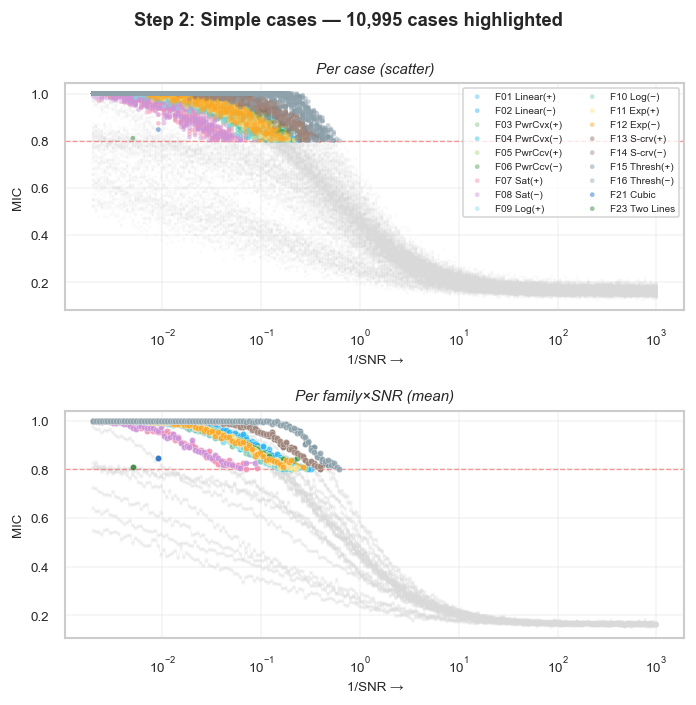

In [1070]:
# ── Step 2 可视化: Simple cases ──
plot_mic_highlight(simple_cases, f'Step 2: Simple cases — {len(simple_cases):,} cases highlighted')


In [1071]:
# ── ◇ Direction (sign of Pearson r) ──
simple_cases['direction'] = np.where(simple_cases['pearson_r'] > 0, 'Positive', 'Negative')

print(f'═══ Step 3: Direction (sign of Pearson r) ═══')
print()

hdr = f'{"Family":<16} {"Pos(+)":>7} {"Neg(−)":>7} {"Total":>7} {"Majority":>9}'
sep = '─' * len(hdr)
rows = []
for fid in simple_fids:
    sub = simple_cases[simple_cases['family_id'] == fid]
    n = len(sub)
    n_pos = int((sub['direction'] == 'Positive').sum())
    n_neg = int((sub['direction'] == 'Negative').sum())
    maj = '+' if n_pos >= n_neg else '−'
    rows.append(f'{fid} {SHORT[fid]:<10} {n_pos:>7,} {n_neg:>7,} {n:>7,} {maj:>9}')

mid = (len(rows) + 1) // 2
col_w = len(hdr)
print(f'{hdr:<{col_w}}  {hdr}')
print(f'{sep}  {sep}')
for i in range(mid):
    left = rows[i]
    right = rows[i + mid] if i + mid < len(rows) else ''
    print(f'{left:<{col_w}}  {right}')


═══ Step 3: Direction (sign of Pearson r) ═══

Family            Pos(+)  Neg(−)   Total  Majority  Family            Pos(+)  Neg(−)   Total  Majority
──────────────────────────────────────────────────  ──────────────────────────────────────────────────
F01 Linear(+)      718       0     718         +    F10 Log(−)           0     645     645         −
F02 Linear(−)        0     725     725         −    F11 Exp(+)         675       0     675         +
F03 PwrCvx(+)      645       0     645         +    F12 Exp(−)           0     676     676         −
F04 PwrCvx(−)        0     651     651         −    F13 S-crv(+)       789       0     789         +
F05 PwrCcv(+)      673       0     673         +    F14 S-crv(−)         0     796     796         −
F06 PwrCcv(−)        0     678     678         −    F15 Thresh(+)      833       0     833         +
F07 Sat(+)         502       0     502         +    F16 Thresh(−)        0     842     842         −
F08 Sat(−)           0     496     496  

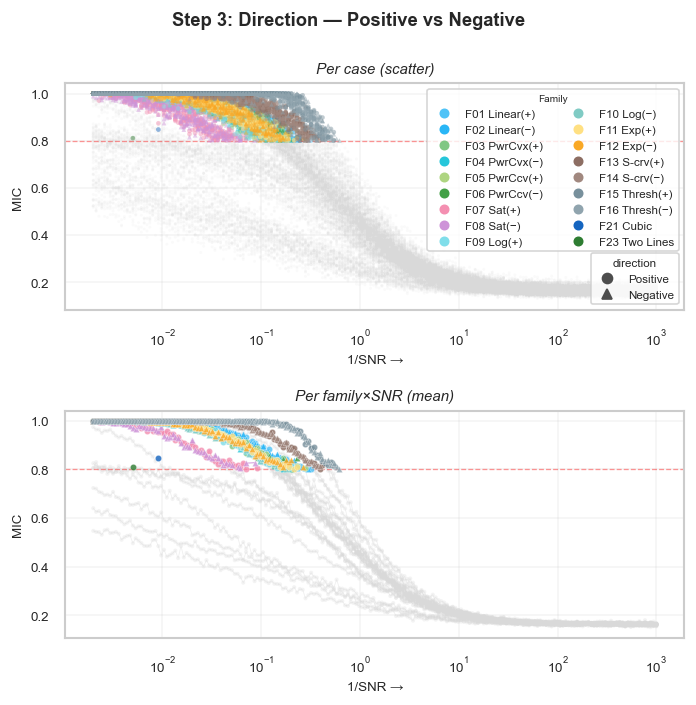

In [1072]:
# ── Step 3 可视化: Direction ──
plot_mic_highlight(simple_cases, f'Step 3: Direction — Positive vs Negative',
                   hue_col='direction',
                   hue_palette={'Positive': '#4FC3F7', 'Negative': '#EF5350'})


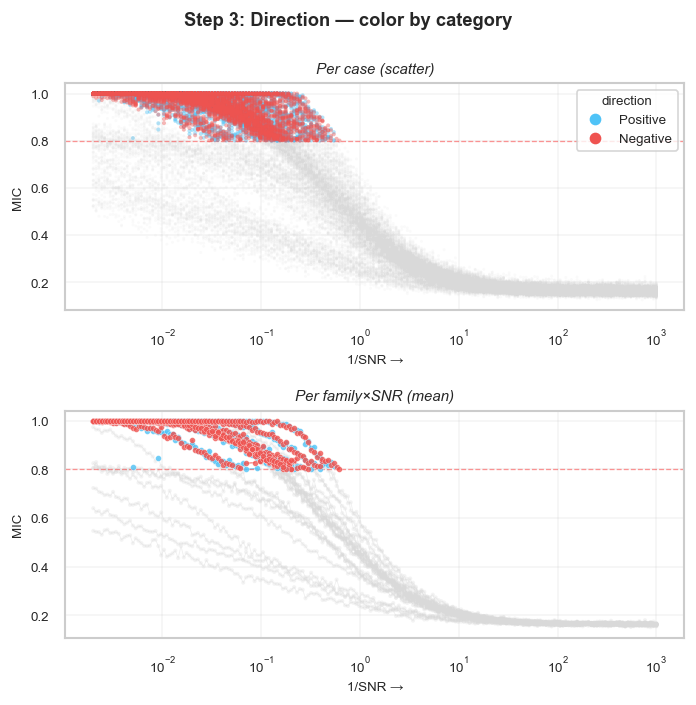

In [1073]:
# ── Step 3 颜色区分: Direction ──
plot_mic_highlight(simple_cases, f'Step 3: Direction — color by category',
                   hue_col='direction',
                   hue_palette={'Positive': '#4FC3F7', 'Negative': '#EF5350'},
                   color_mode='hue')


In [1074]:
# ── ◇ Monotonicity (|ρ| level) ──
MONO_STRONG = 0.9

simple_cases['monotonicity'] = np.where(
    simple_cases['spearman_rho'].abs() >= MONO_STRONG, 'Strong', 'Med'
)

print(f'═══ Step 4: Monotonicity (|ρ| ≥ {MONO_STRONG} → Strong) ═══')
print()

hdr = f'{"Family":<16} {"Strong":>7} {"Med":>7} {"Total":>7} {"Majority":>9}'
sep = '─' * len(hdr)
rows = []
for fid in simple_fids:
    sub = simple_cases[simple_cases['family_id'] == fid]
    n = len(sub)
    n_s = int((sub['monotonicity'] == 'Strong').sum())
    n_m = int((sub['monotonicity'] == 'Med').sum())
    maj = 'Strong' if n_s >= n_m else 'Med'
    rows.append(f'{fid} {SHORT[fid]:<10} {n_s:>7,} {n_m:>7,} {n:>7,} {maj:>9}')

mid = (len(rows) + 1) // 2
col_w = len(hdr)
print(f'{hdr:<{col_w}}  {hdr}')
print(f'{sep}  {sep}')
for i in range(mid):
    left = rows[i]
    right = rows[i + mid] if i + mid < len(rows) else ''
    print(f'{left:<{col_w}}  {right}')


═══ Step 4: Monotonicity (|ρ| ≥ 0.9 → Strong) ═══

Family            Strong     Med   Total  Majority  Family            Strong     Med   Total  Majority
──────────────────────────────────────────────────  ──────────────────────────────────────────────────
F01 Linear(+)      716       2     718    Strong    F10 Log(−)         645       0     645    Strong
F02 Linear(−)      723       2     725    Strong    F11 Exp(+)         670       5     675    Strong
F03 PwrCvx(+)      621      24     645    Strong    F12 Exp(−)         671       5     676    Strong
F04 PwrCvx(−)      621      30     651    Strong    F13 S-crv(+)       704      85     789    Strong
F05 PwrCcv(+)      672       1     673    Strong    F14 S-crv(−)       697      99     796    Strong
F06 PwrCcv(−)      678       0     678    Strong    F15 Thresh(+)        0     833     833       Med
F07 Sat(+)         433      69     502    Strong    F16 Thresh(−)        0     842     842       Med
F08 Sat(−)         441      55     4

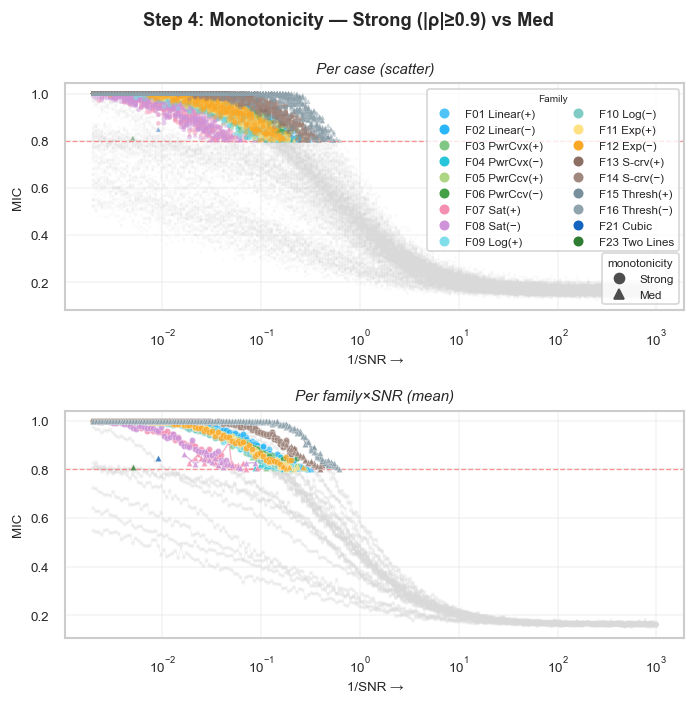

In [1075]:
# ── Step 4 可视化: Monotonicity ──
plot_mic_highlight(simple_cases, f'Step 4: Monotonicity — Strong (|ρ|≥{MONO_STRONG}) vs Med',
                   hue_col='monotonicity',
                   hue_palette={'Strong': '#66BB6A', 'Med': '#FFA726'})


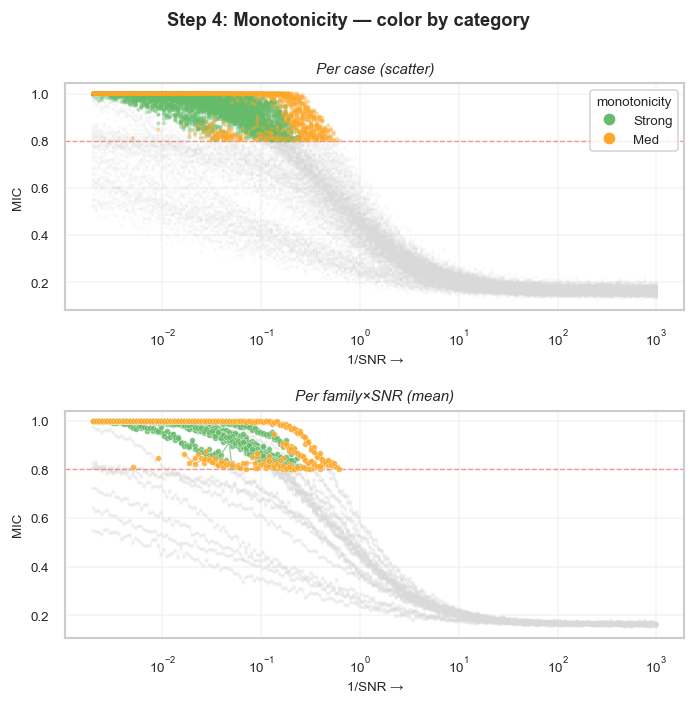

In [1076]:
# ── Step 4 颜色区分: Monotonicity ──
plot_mic_highlight(simple_cases, f'Step 4: Monotonicity — color by category',
                   hue_col='monotonicity',
                   hue_palette={'Strong': '#66BB6A', 'Med': '#FFA726'},
                   color_mode='hue')


In [1077]:
# ── ◇ Linearity (|r| level) ──
LIN_STRONG = 0.9

simple_cases['linearity'] = np.where(
    simple_cases['pearson_r'].abs() >= LIN_STRONG, 'Line', 'Med'
)

print(f'═══ Step 5: Linearity (|r| ≥ {LIN_STRONG} → Line) ═══')
print()

hdr = f'{"Family":<16} {"Line":>7} {"Med":>7} {"Total":>7} {"Majority":>9}'
sep = '─' * len(hdr)
rows = []
for fid in simple_fids:
    sub = simple_cases[simple_cases['family_id'] == fid]
    n = len(sub)
    n_l = int((sub['linearity'] == 'Line').sum())
    n_m = int((sub['linearity'] == 'Med').sum())
    maj = 'Line' if n_l >= n_m else 'Med'
    rows.append(f'{fid} {SHORT[fid]:<10} {n_l:>7,} {n_m:>7,} {n:>7,} {maj:>9}')

mid = (len(rows) + 1) // 2
col_w = len(hdr)
print(f'{hdr:<{col_w}}  {hdr}')
print(f'{sep}  {sep}')
for i in range(mid):
    left = rows[i]
    right = rows[i + mid] if i + mid < len(rows) else ''
    print(f'{left:<{col_w}}  {right}')


═══ Step 5: Linearity (|r| ≥ 0.9 → Line) ═══

Family              Line     Med   Total  Majority  Family              Line     Med   Total  Majority
──────────────────────────────────────────────────  ──────────────────────────────────────────────────
F01 Linear(+)      714       4     718      Line    F10 Log(−)         640       5     645      Line
F02 Linear(−)      720       5     725      Line    F11 Exp(+)         663      12     675      Line
F03 PwrCvx(+)      607      38     645      Line    F12 Exp(−)         664      12     676      Line
F04 PwrCvx(−)      604      47     651      Line    F13 S-crv(+)       711      78     789      Line
F05 PwrCcv(+)      670       3     673      Line    F14 S-crv(−)       705      91     796      Line
F06 PwrCcv(−)      676       2     678      Line    F15 Thresh(+)      319     514     833       Med
F07 Sat(+)           0     502     502       Med    F16 Thresh(−)      335     507     842       Med
F08 Sat(−)           0     496     496   

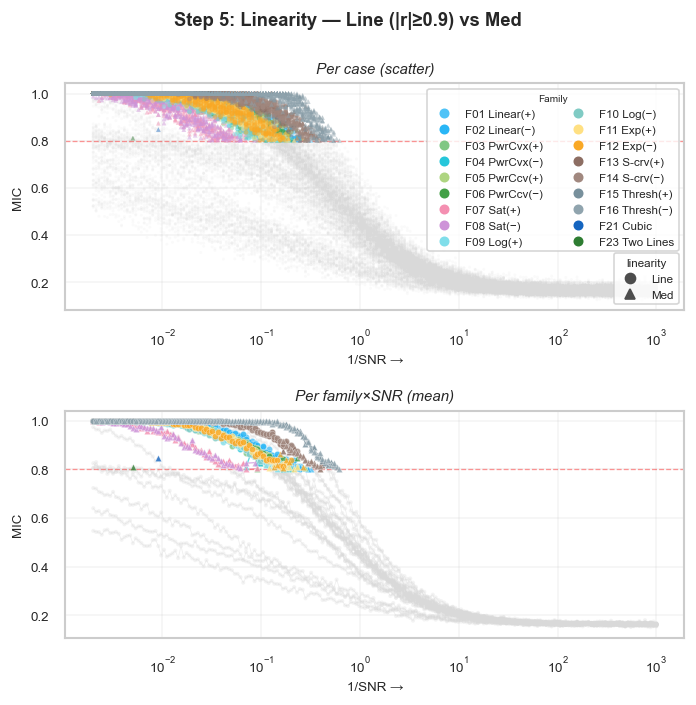

In [1078]:
# ── Step 5 可视化: Linearity ──
plot_mic_highlight(simple_cases, f'Step 5: Linearity — Line (|r|≥{LIN_STRONG}) vs Med',
                   hue_col='linearity',
                   hue_palette={'Line': '#42A5F5', 'Med': '#FF7043'})


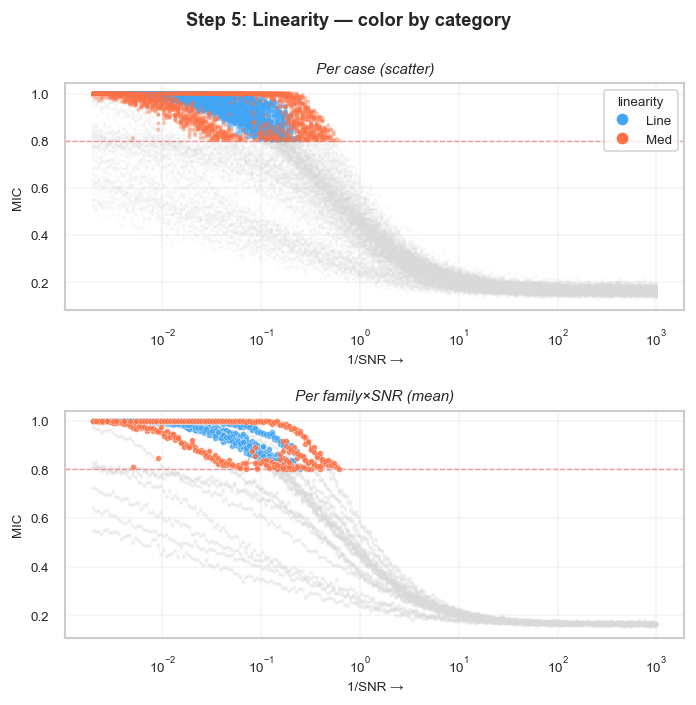

In [1079]:
# ── Step 5 颜色区分: Linearity ──
plot_mic_highlight(simple_cases, f'Step 5: Linearity — color by category',
                   hue_col='linearity',
                   hue_palette={'Line': '#42A5F5', 'Med': '#FF7043'},
                   color_mode='hue')


In [1080]:
# ── ◇ Line判定 + Curvature ──
# Line: 多指标 + 可选 slope V_s
# Curvature: 要求 V_s 足够大 + margin，否则 Weak/Uncertain

# ── Line 参数 ──
LINE_MIC_R2   = 0.15   # MIC - r² < this
LINE_MAS      = 0.15   # MAS < this
LINE_RHO_R    = 0.03   # |ρ| - |r| < this
USE_SLOPE_CHECK = True  # ← 开关: True = 额外检查 V_s
LINE_VS_TOL   = 0.25   # V_s < this → slopes consistent enough for Line

# ── Curvature 参数 ──
CURVE_VS_MIN  = 0.35   # V_s ≥ this 才分 curvature，否则 Weak/Uncertain
CURVE_MARGIN  = 0.10   # slope 之间差 > margin 才算明确 ordering

# ── Compute normalized direction-aware slopes ──
E_raw = simple_cases['standardized_polyfit_early_slope'].values
M_raw = simple_cases['standardized_polyfit_middle_slope'].values
L_raw = simple_cases['standardized_polyfit_late_slope'].values

scale = np.maximum(np.maximum(np.abs(E_raw), np.abs(M_raw)), np.abs(L_raw))
scale = np.where(scale == 0, 1, scale)
e_n, m_n, l_n = E_raw / scale, M_raw / scale, L_raw / scale

dsign = np.where(simple_cases['pearson_r'].values > 0, 1, -1)
e_d = e_n * dsign
m_d = m_n * dsign
l_d = l_n * dsign

simple_cases['e_d'] = e_d
simple_cases['m_d'] = m_d
simple_cases['l_d'] = l_d

# ── V_s ──
EPS = 1e-8
slopes = np.column_stack([e_d, m_d, l_d])
slope_mean = np.abs(slopes.mean(axis=1))
slope_sd   = slopes.std(axis=1, ddof=0)
V_s = slope_sd / (slope_mean + EPS)
simple_cases['slope_Vs'] = V_s

# ── Line候选 ──
is_candidate = (
    (simple_cases['monotonicity'] == 'Strong') &
    (simple_cases['linearity'] == 'Line') &
    (simple_cases['MIC_minus_r2'] < LINE_MIC_R2) &
    (simple_cases['MAS'] < LINE_MAS) &
    ((simple_cases['spearman_rho'].abs() - simple_cases['pearson_r'].abs()) < LINE_RHO_R)
)

if USE_SLOPE_CHECK:
    is_line = is_candidate & (V_s < LINE_VS_TOL)
else:
    is_line = is_candidate

# ── Shape classification ──
shape = np.full(len(simple_cases), 'Weak/Uncertain', dtype=object)
shape[is_line] = 'Line'

not_line = (shape == 'Weak/Uncertain')
curve_ready = not_line & (V_s >= CURVE_VS_MIN)
mg = CURVE_MARGIN

shape[curve_ready & (e_d + mg < m_d) & (m_d + mg < l_d)] = 'Convex'
shape[curve_ready & (e_d > m_d + mg) & (m_d > l_d + mg)] = 'Concave'
shape[curve_ready & (m_d > e_d + mg) & (m_d > l_d + mg)] = 'Inflected'
shape[curve_ready & (m_d < e_d - mg) & (m_d < l_d - mg)] = 'U-shape'

simple_cases['shape'] = shape

line_cases = simple_cases[simple_cases['shape'] == 'Line'].copy()
med_cases = simple_cases[simple_cases['shape'] != 'Line'].copy()

# ── Print ──
slope_str = f' + V_s < {LINE_VS_TOL}' if USE_SLOPE_CHECK else ''
print(f'═══ Step 6: Line判定 + Curvature ═══')
print(f'Line: |ρ|≥{MONO_STRONG} AND |r|≥{LIN_STRONG} AND MIC-r²<{LINE_MIC_R2} AND MAS<{LINE_MAS} AND |ρ|-|r|<{LINE_RHO_R}{slope_str}')
print(f'Curvature: V_s ≥ {CURVE_VS_MIN} AND margin > {CURVE_MARGIN}')
print(f'Weak/Uncertain: V_s < {CURVE_VS_MIN} 或 ordering 不明确')
print()

all_shapes = ['Line', 'Convex', 'Concave', 'Inflected', 'U-shape', 'Weak/Uncertain']
for s in all_shapes:
    n = int((simple_cases['shape'] == s).sum())
    print(f'  {s:<16} {n:>6,} ({n/len(simple_cases):>5.1%})')
print(f'  {"Total":<16} {len(simple_cases):>6,}')
print()

hdr = f'{"Family":<16} {"Line":>6} {"Convex":>7} {"Concave":>8} {"Inflect":>8} {"U-shp":>6} {"Weak":>6} {"Total":>7} {"Majority":>16}'
sep = '─' * len(hdr)
rows = []
for fid in simple_fids:
    sub = simple_cases[simple_cases['family_id'] == fid]
    n = len(sub)
    counts = {s: int((sub['shape'] == s).sum()) for s in all_shapes}
    maj = sub['shape'].mode().iloc[0]
    rows.append(f'{fid} {SHORT[fid]:<10} {counts["Line"]:>6,} {counts["Convex"]:>7,} {counts["Concave"]:>8,} {counts["Inflected"]:>8,} {counts["U-shape"]:>6,} {counts["Weak/Uncertain"]:>6,} {n:>7,} {maj:>16}')

mid = (len(rows) + 1) // 2
col_w = len(hdr)
print(f'{hdr:<{col_w}}  {hdr}')
print(f'{sep}  {sep}')
for i in range(mid):
    left = rows[i]
    right = rows[i + mid] if i + mid < len(rows) else ''
    print(f'{left:<{col_w}}  {right}')


═══ Step 6: Line判定 + Curvature ═══
Line: |ρ|≥0.9 AND |r|≥0.9 AND MIC-r²<0.15 AND MAS<0.15 AND |ρ|-|r|<0.03 + V_s < 0.25
Curvature: V_s ≥ 0.35 AND margin > 0.1
Weak/Uncertain: V_s < 0.35 或 ordering 不明确

  Line              1,435 (13.1%)
  Convex            2,644 (24.0%)
  Concave           3,268 (29.7%)
  Inflected         3,260 (29.6%)
  U-shape               1 ( 0.0%)
  Weak/Uncertain      387 ( 3.5%)
  Total            10,995

Family             Line  Convex  Concave  Inflect  U-shp   Weak   Total         Majority  Family             Line  Convex  Concave  Inflect  U-shp   Weak   Total         Majority
────────────────────────────────────────────────────────────────────────────────────────  ────────────────────────────────────────────────────────────────────────────────────────
F01 Linear(+)     714       0        0        0      0      4     718             Line    F10 Log(−)          0       0      623        0      0     22     645          Concave
F02 Linear(−)     720       0   

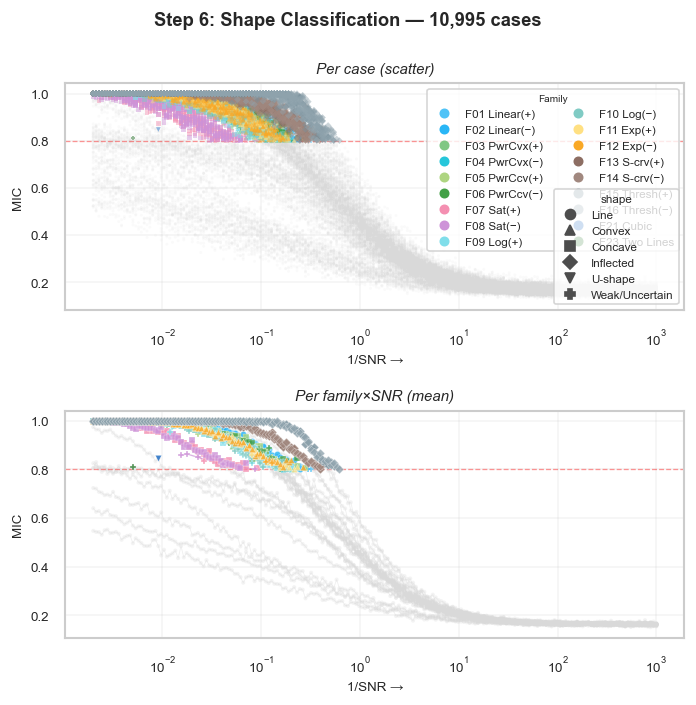

In [1081]:
# ── Step 6 可视化: Shape ──
shape_palette = {
    'Line': '#4FC3F7', 'Convex': '#81C784', 'Concave': '#CE93D8',
    'Inflected': '#EF9A9A', 'U-shape': '#FFB74D', 'Weak/Uncertain': '#BDBDBD'
}
plot_mic_highlight(simple_cases, f'Step 6: Shape Classification — {len(simple_cases):,} cases',
                   hue_col='shape', hue_palette=shape_palette)


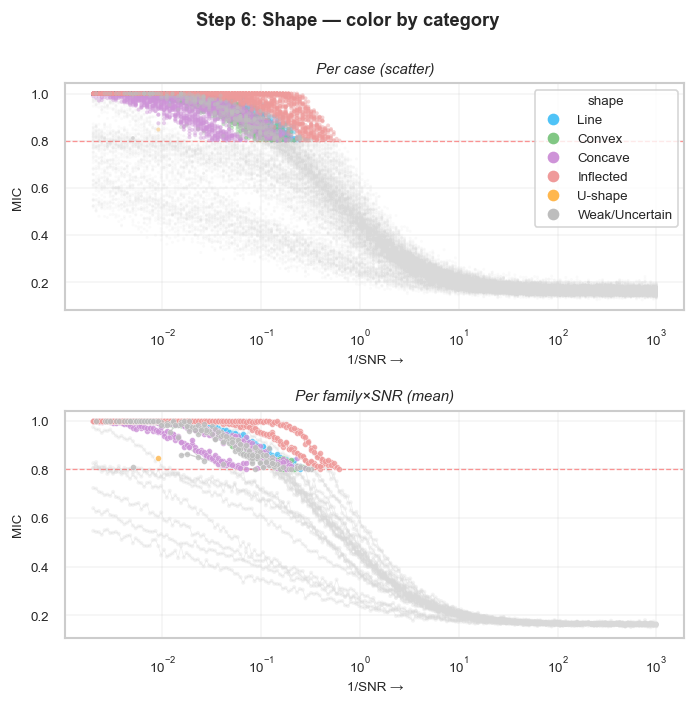

In [1082]:
# ── Step 6 颜色区分: Shape ──
shape_palette = {
    'Line': '#4FC3F7', 'Convex': '#81C784', 'Concave': '#CE93D8',
    'Inflected': '#EF9A9A', 'U-shape': '#FFB74D', 'Weak/Uncertain': '#BDBDBD'
}
plot_mic_highlight(simple_cases, f'Step 6: Shape — color by category',
                   hue_col='shape', hue_palette=shape_palette,
                   color_mode='hue')


In [1083]:
# ── Classification Summary ──
print(f'═══ Classification Summary ═══')
print(f'Variant levels: {[l for l in ["strong","standard","mild"] if l in filtered_cases["variant_level"].values]}')
print(f'Filter: MIC ≥ {MIC_THRESH}, dcor ≥ {DCOR_THRESH}')
print(f'Filtered: {len(filtered_cases):,} / {len(signal):,}')
print(f'Simple: {len(simple_cases):,} / {len(filtered_cases):,}')
print()

hdr = f'{"Family":<16} {"Filter":>7} {"Simple":>7} {"Dir":>4} {"Mono":>6} {"Lin":>5} {"Shape":>16} {"Profile"}'
print(hdr)
print('─' * len(hdr))
for fid in qual_fids:
    filt_n = len(filtered_cases[filtered_cases['family_id'] == fid])
    fid_simple = simple_cases[simple_cases['family_id'] == fid]
    n_s = len(fid_simple)
    if n_s == 0:
        print(f'{fid} {SHORT[fid]:<10} {filt_n:>7,} {n_s:>7,} {"—":>4} {"—":>6} {"—":>5} {"—":>16}  —')
        continue
    dr = '+' if (fid_simple['direction'] == 'Positive').sum() >= (fid_simple['direction'] == 'Negative').sum() else '−'
    mo = fid_simple['monotonicity'].mode().iloc[0]
    li = fid_simple['linearity'].mode().iloc[0]
    sh = fid_simple['shape'].mode().iloc[0]
    profile = f'{dr}, {mo}, {sh}'
    print(f'{fid} {SHORT[fid]:<10} {filt_n:>7,} {n_s:>7,} {dr:>4} {mo:>6} {li:>5} {sh:>16}  {profile}')


═══ Classification Summary ═══
Variant levels: ['standard']
Filter: MIC ≥ 0.8, dcor ≥ 0
Filtered: 13,777 / 52,260
Simple: 10,995 / 13,777

Family            Filter  Simple  Dir   Mono   Lin            Shape Profile
───────────────────────────────────────────────────────────────────────────
F01 Linear(+)      718     718    + Strong  Line             Line  +, Strong, Line
F02 Linear(−)      725     725    − Strong  Line             Line  −, Strong, Line
F03 PwrCvx(+)      645     645    + Strong  Line           Convex  +, Strong, Convex
F04 PwrCvx(−)      651     651    − Strong  Line           Convex  −, Strong, Convex
F05 PwrCcv(+)      673     673    + Strong  Line          Concave  +, Strong, Concave
F06 PwrCcv(−)      678     678    − Strong  Line          Concave  −, Strong, Concave
F07 Sat(+)         502     502    + Strong   Med          Concave  +, Strong, Concave
F08 Sat(−)         496     496    − Strong   Med          Concave  −, Strong, Concave
F09 Log(+)         649     64